# 🚚 Optimizing Delivery ETAs with Graph-Based Network Intelligence
### Delhivery Logistics Network Analytics & ETA Optimization System


**Objective:** Build a graph-based intelligence system that (1) improves ETA prediction
over the OSRM baseline, (2) identifies bottleneck hubs and delayed corridors using
network science, (3) builds an FTL vs Carting decision framework, and (4) translates
all findings into quantified business recommendations for Delhivery's Network
Operations leadership.

---

## 📐 Solution Architecture

```
┌─────────────────────────────────────────────────────────────────────────┐
│  RAW TRIP-SEGMENT DATA (144,867 rows)                                     │
└───────────────────────────────┬───────────────────────────────────────--┘
                                  │
                ┌─────────────────┴─────────────────┐
                ▼                                     ▼
   ┌─────────────────────────┐         ┌─────────────────────────────┐
   │  TABULAR FEATURE TRACK    │         │   GRAPH TRACK                │
   │  - Cleaning & EDA         │         │  - Build directed graph       │
   │  - Delay / time features  │         │    (center -> center)         │
   │  - Trip-level aggregation │         │  - Centrality / PageRank      │
   └────────────┬──────────────┘         │  - Bottleneck detection       │
                │                         │  - Node2Vec embeddings        │
                │                         └───────────────┬───────────────┘
                │                                          │
                ▼                                          ▼
   ┌─────────────────────────┐         ┌─────────────────────────────┐
   │ BASELINE ETA MODEL        │         │ GRAPH-ENHANCED ETA MODEL      │
   │ RF + XGBoost on tabular   │   vs    │ XGBoost on tabular +          │
   │ features                  │         │ Node2Vec embeddings           │
   └────────────┬──────────────┘         └───────────────┬───────────────┘
                │                                          │
                └───────────────────┬──────────────────────┘
                                     ▼
                  ┌───────────────────────────────────────┐
                  │  FTL vs CARTING DECISION FRAMEWORK      │
                  │  + BUSINESS IMPACT SIMULATION           │
                  │  + EXECUTIVE INSIGHTS + STREAMLIT APP   │
                  │  + STRATEGY MEMO                        │
                  └───────────────────────────────────────┘
```

**Design Philosophy**

1. **Two parallel intelligence tracks** — a *tabular* track (classic feature
   engineering + gradient boosting) and a *graph* track (NetworkX corridor graph +
   Node2Vec). They are fused in Section 11 to test whether *network topology*
   carries predictive signal beyond what trip-level features already capture.
2. **Corridor = directed edge** (`source_center → destination_center`). This is the
   natural unit for Delhivery's hub-and-spoke network — it lets us reason about
   *where* delays concentrate, not just *how much* delay exists on average.
3. **Everything is reproducible** — every section can be re-run top-to-bottom on
   Colab with only the dataset path changed.
4. **Outputs are explicitly marked** with `# >>> INSERT OUTPUT / SCREENSHOT HERE <<<`
   so that after execution, the notebook can be exported with results embedded for
   the competition submission.

---


## SECTION 1 — Environment Setup: Imports, Google Drive Mount & Package Installation

**Design choice:** We install only what's missing in the default Colab image
(`xgboost`, `node2vec`, `gensim`, `pyvis` for interactive network viz, and
`streamlit` purely so Section 16's code is importable/testable in-notebook).
GraphSAGE (Section 10 optional extension) needs `torch` + `torch_geometric`,
which we install in a **separate, optional cell** so the main pipeline never
breaks if that install fails (PyG wheels are version/CUDA-sensitive on Colab).


In [1]:
# ── 1.2 Core imports ─────────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Graph
import networkx as nx

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
import xgboost as xgb

# Graph embeddings
!pip install node2vec
from node2vec import Node2Vec

warnings.filterwarnings("ignore")

# ── 1.3 Global plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# ── 1.4 Reproducibility ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")
print("NetworkX :", nx.__version__)
print("XGBoost  :", xgb.__version__)


Environment ready.
NetworkX : 3.6.1
XGBoost  : 3.2.0


In [2]:
# ── 1.5 (Optional) Mount Google Drive ────────────────────────────────────────────────────
# Run this ONLY if your dataset lives in Google Drive. If you're uploading the CSV
# directly via Colab's file upload widget, you can skip this cell.
from google.colab import drive
drive.mount('/content/drive')

# Set this to the folder containing 'delivery_data.csv'
DATA_DIR = '/content/drive/MyDrive/ETA PROJECT'


Mounted at /content/drive


In [3]:
# ── 1.6 (Optional) GraphSAGE dependencies — run only if attempting Section 10's
#         optional extension. Wrapped in try/except so a failed install never
#         blocks the main Node2Vec-based pipeline.
try:
    import torch
    print("Torch already available:", torch.__version__)
except ImportError:
    !pip install -q torch --index-url https://download.pytorch.org/whl/cpu

try:
    import torch_geometric
    print("PyG already available:", torch_geometric.__version__)
except ImportError:
    !pip install -q torch_geometric


Torch already available: 2.11.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.9 MB/s eta 0:00:00


---
## SECTION 2 — Dataset Loading & Inspection

**About the data:** Each row is a *segment* of a *trip*. A trip (`trip_uuid`) is
broken into one or more segments, each moving the shipment from one facility
(`source_center`) to the next (`destination_center`). `actual_time` /
`segment_actual_time` are the ground-truth durations we want to predict/explain,
while `osrm_time` / `segment_osrm_time` are OSRM's (a routing engine) estimates —
our benchmark to beat.

**Design choice:** We load the full CSV directly (144,867 rows is small enough for
in-memory pandas on Colab — no chunking needed). We immediately parse all datetime
columns since almost every downstream feature (time-of-day, day-of-week, peak hour)
depends on them.


In [4]:
# ── 2.1 Load the dataset ─────────────────────────────────────────────────────────────────
# If using Drive:        FILE_PATH = os.path.join(DATA_DIR, 'delivery_data.csv')
# If uploaded directly:  FILE_PATH = '/content/delivery_data.csv'
FILE_PATH = '/content/drive/MyDrive/ETA PROJECT/delivery_data.csv'   # <-- adjust path as needed

df = pd.read_csv(FILE_PATH)

print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
df.head()


Shape: 144,867 rows  x  24 columns


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [5]:
# ── 2.2 Parse datetime columns ───────────────────────────────────────────────────────────
datetime_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for c in datetime_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# ── 2.3 Schema overview ──────────────────────────────────────────────────────────────────
print("Column dtypes:\n")
print(df.dtypes)
print("\nMemory usage: {:.2f} MB".format(df.memory_usage(deep=True).sum() / 1e6))


Column dtypes:

data                                      object
trip_creation_time                datetime64[ns]
route_schedule_uuid                       object
route_type                                object
trip_uuid                                 object
source_center                             object
source_name                               object
destination_center                        object
destination_name                          object
od_start_time                     datetime64[ns]
od_end_time                       datetime64[ns]
start_scan_to_end_scan                   float64
is_cutoff                                   bool
cutoff_factor                              int64
cutoff_timestamp                  datetime64[ns]
actual_distance_to_destination           float64
actual_time                              float64
osrm_time                                float64
osrm_distance                            float64
factor                                   float64
segm

In [6]:
# ── 2.4 Basic descriptive statistics for numeric columns ────────────────────────────────
df.describe().T


,count,mean,min,25%,50%,75%,max,std
trip_creation_time,144867,2018-09-22 13:34:23.659819264,2018-09-12 00:00:16.535741,2018-09-17 03:20:51.775845888,2018-09-22 04:24:27.932764928,2018-09-27 17:57:56.350054912,2018-10-03 23:59:42.701692,NaN
od_start_time,144867,2018-09-22 18:02:45.855230720,2018-09-12 00:00:16.535741,2018-09-17 08:05:40.886155008,2018-09-22 08:53:00.116656128,2018-09-27 22:41:50.285857024,2018-10-06 04:27:23.392375,NaN
od_end_time,144867,2018-09-23 10:04:31.395393024,2018-09-12 00:50:10.814399,2018-09-18 01:48:06.410121984,2018-09-23 03:13:03.520212992,2018-09-28 12:49:06.054018048,2018-10-08 03:00:24.353479,NaN
start_scan_to_end_scan,144867.0,961.262986,20.0,161.0,449.0,1634.0,7898.0,1037.012769
cutoff_factor,144867.0,232.926567,9.0,22.0,66.0,286.0,1927.0,344.755577
cutoff_timestamp,141438,2018-09-23 03:43:41.794807552,2018-09-12 00:10:27,2018-09-17 19:52:04.750000128,2018-09-22 22:02:55,2018-09-28 06:37:55,2018-10-06 23:44:12,NaN
actual_distance_to_destination,144867.0,234.073372,9.000045,23.355874,66.126571,286.708875,1927.447705,344.990009
actual_time,144867.0,416.927527,9.0,51.0,132.0,513.0,4532.0,598.103621
osrm_time,144867.0,213.868272,6.0,27.0,64.0,257.0,1686.0,308.011085
osrm_distance,144867.0,284.771297,9.0082,29.9147,78.5258,343.19325,2326.1991,421.119294


In [7]:
# ── 2.5 Cardinality check — understand the network's scale ──────────────────────────────
print("Unique trips                :", df['trip_uuid'].nunique())
print("Unique route_schedule_uuid  :", df['route_schedule_uuid'].nunique())
print("Unique source centers       :", df['source_center'].nunique())
print("Unique destination centers  :", df['destination_center'].nunique())
print("Unique (source, dest) pairs :", df.groupby(['source_center', 'destination_center']).ngroups)
print("Route types                 :", df['route_type'].unique())
print("Data split values ('data')  :", df['data'].unique())


Unique trips                : 14817
Unique route_schedule_uuid  : 1504
Unique source centers       : 1508
Unique destination centers  : 1481
Unique (source, dest) pairs : 2783
Route types                 : ['Carting' 'FTL']
Data split values ('data')  : ['training' 'test']


In [8]:
# ── 2.6 Sanity check on time window of the data ─────────────────────────────────────────
print("Trip creation time range:", df['trip_creation_time'].min(), "to", df['trip_creation_time'].max())


Trip creation time range: 2018-09-12 00:00:16.535741 to 2018-10-03 23:59:42.701692


---
## SECTION 3 — Comprehensive Exploratory Data Analysis

We examine: missing values, duplicates, route-type distribution, facility-level
activity, delay patterns (actual vs OSRM), key distributions, and correlations.
This grounds every later modeling and graph decision in the data's actual shape.


In [9]:
# ── 3.1 Missing values ───────────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print("Columns with missing values:")
missing_df


Columns with missing values:


,missing_count,missing_pct
cutoff_timestamp,3429,2.37
source_name,293,0.20
destination_name,261,0.18


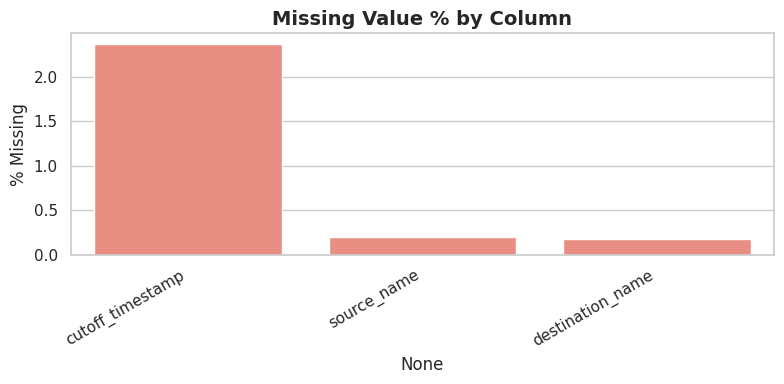

In [10]:
# ── 3.1b Visualize missingness ───────────────────────────────────────────────────────────
if len(missing_df) > 0:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_df.index, y='missing_pct', data=missing_df, color='salmon')
    plt.title("Missing Value % by Column")
    plt.ylabel("% Missing")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


In [11]:
# ── 3.2 Duplicate rows ────────────────────────────────────────────────────────────────────
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes:,} ({full_dupes/len(df)*100:.3f}%)")

# Duplicate trip+segment combos (same trip moving same source->dest more than once)
seg_key_cols = ['trip_uuid', 'source_center', 'destination_center', 'segment_actual_time']
seg_dupes = df.duplicated(subset=seg_key_cols).sum()
print(f"Duplicate trip-segment combos: {seg_dupes:,} ({seg_dupes/len(df)*100:.3f}%)")


Fully duplicated rows: 0 (0.000%)
Duplicate trip-segment combos: 28,518 (19.686%)


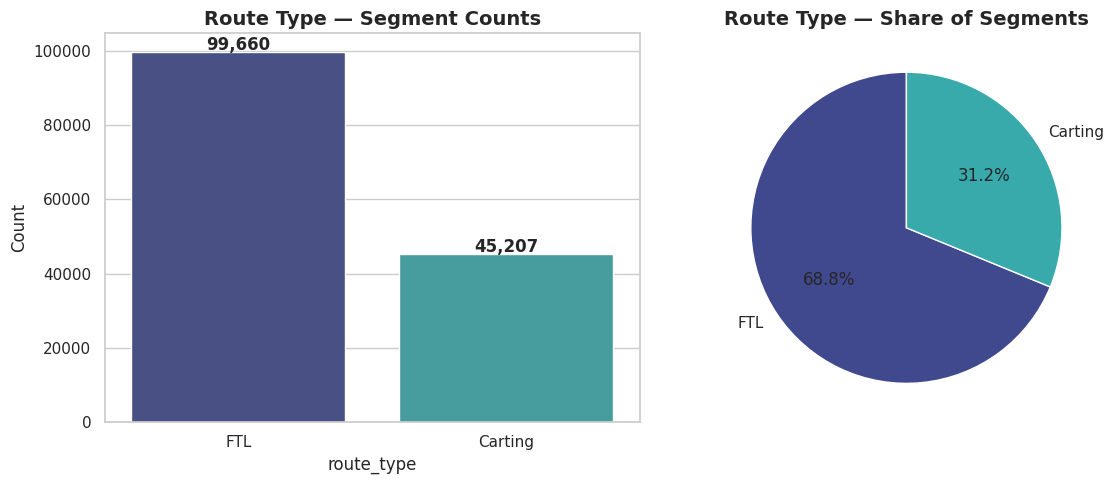

route_type
FTL        68.79
Carting    31.21
Name: count, dtype: float64


In [12]:
# ── 3.3 Route type distribution ──────────────────────────────────────────────────────────
route_counts = df['route_type'].value_counts()
route_pct = (route_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=route_counts.index, y=route_counts.values, ax=axes[0], palette='mako')
axes[0].set_title("Route Type — Segment Counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(route_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

axes[1].pie(route_counts.values, labels=route_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('mako', len(route_counts)), startangle=90)
axes[1].set_title("Route Type — Share of Segments")

plt.tight_layout()
plt.show()

print(route_pct)
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


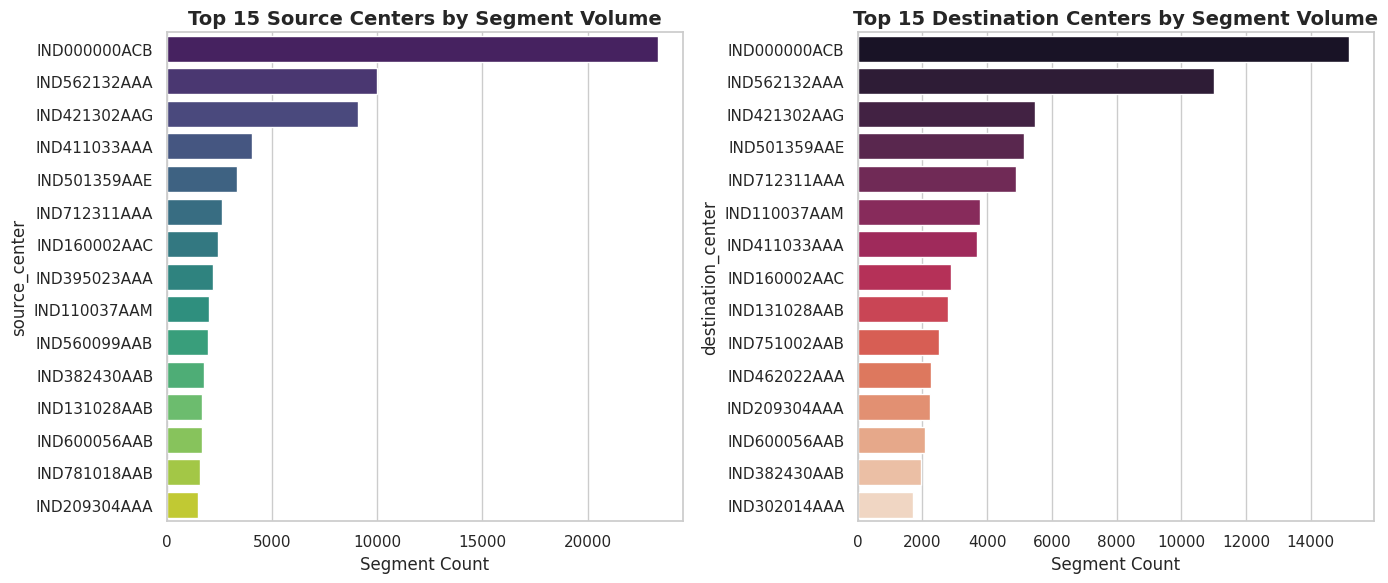

In [13]:
# ── 3.4 Facility analysis: busiest source & destination centers ─────────────────────────
top_sources = df['source_center'].value_counts().head(15)
top_destinations = df['destination_center'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top_sources.values, y=top_sources.index, ax=axes[0], palette='viridis')
axes[0].set_title("Top 15 Source Centers by Segment Volume")
axes[0].set_xlabel("Segment Count")

sns.barplot(x=top_destinations.values, y=top_destinations.index, ax=axes[1], palette='rocket')
axes[1].set_title("Top 15 Destination Centers by Segment Volume")
axes[1].set_xlabel("Segment Count")

plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


In [14]:
# ── 3.4b Facility role: hubs that act heavily as BOTH source and destination ────────────
src_counts = df['source_center'].value_counts().rename('as_source')
dst_counts = df['destination_center'].value_counts().rename('as_destination')
facility_activity = pd.concat([src_counts, dst_counts], axis=1).fillna(0)
facility_activity['total_activity'] = facility_activity['as_source'] + facility_activity['as_destination']
facility_activity = facility_activity.sort_values('total_activity', ascending=False)

print(f"Total unique facilities: {len(facility_activity):,}")
facility_activity.head(10)


Total unique facilities: 1,657


,as_source,as_destination,total_activity
IND000000ACB,23347.0,15192.0,38539.0
IND562132AAA,9975.0,11019.0,20994.0
IND421302AAG,9088.0,5492.0,14580.0
IND501359AAE,3340.0,5142.0,8482.0
IND411033AAA,4061.0,3695.0,7756.0
IND712311AAA,2612.0,4892.0,7504.0
IND110037AAM,2013.0,3769.0,5782.0
IND160002AAC,2450.0,2874.0,5324.0
IND131028AAB,1682.0,2796.0,4478.0
IND751002AAB,1469.0,2524.0,3993.0


In [15]:
# ── 3.5 Delay analysis: actual_time vs osrm_time ─────────────────────────────────────────
# 'factor' = actual_time / osrm_time (already provided). We re-derive it for the segment
# level too, to confirm consistency, and inspect its distribution.
df['trip_delay_ratio_check'] = df['actual_time'] / df['osrm_time'].replace(0, np.nan)

print("Trip-level 'factor' column summary:")
print(df['factor'].describe())

print("\nSegment-level 'segment_factor' summary:")
print(df['segment_factor'].describe())

pct_delayed_trip = (df['factor'] > 1).mean() * 100
pct_delayed_seg = (df['segment_factor'] > 1).mean() * 100
print(f"\n% of rows where actual TRIP time exceeds OSRM estimate    : {pct_delayed_trip:.2f}%")
print(f"% of rows where actual SEGMENT time exceeds OSRM estimate : {pct_delayed_seg:.2f}%")


Trip-level 'factor' column summary:
count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64

Segment-level 'segment_factor' summary:
count    144867.000000
mean          2.218368
std           4.847530
min         -23.444444
25%           1.347826
50%           1.684211
75%           2.250000
max         574.250000
Name: segment_factor, dtype: float64

% of rows where actual TRIP time exceeds OSRM estimate    : 97.84%
% of rows where actual SEGMENT time exceeds OSRM estimate : 89.29%


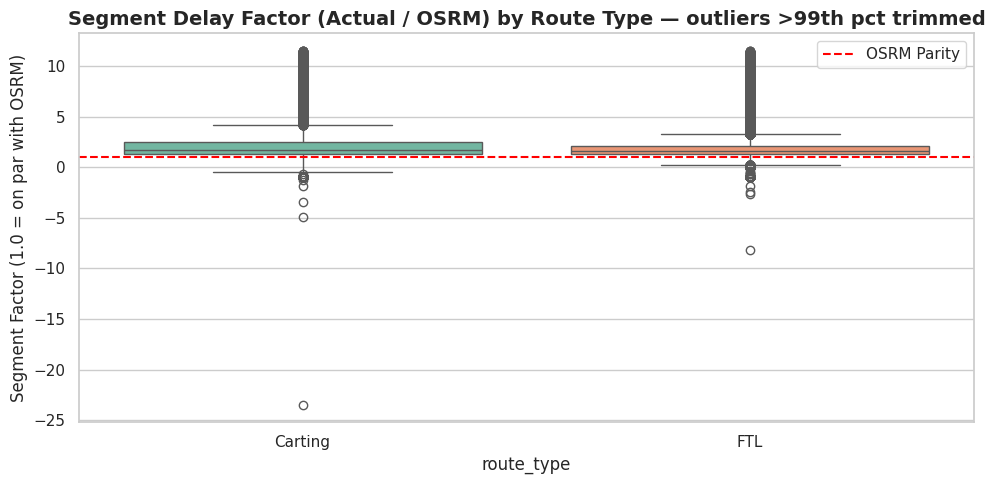

In [16]:
# ── 3.5b Delay distribution by route type ────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.boxplot(x='route_type', y='segment_factor', data=df[df['segment_factor'] < df['segment_factor'].quantile(0.99)],
            palette='Set2')
plt.title("Segment Delay Factor (Actual / OSRM) by Route Type — outliers >99th pct trimmed")
plt.ylabel("Segment Factor (1.0 = on par with OSRM)")
plt.axhline(1.0, color='red', linestyle='--', label='OSRM Parity')
plt.legend()
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


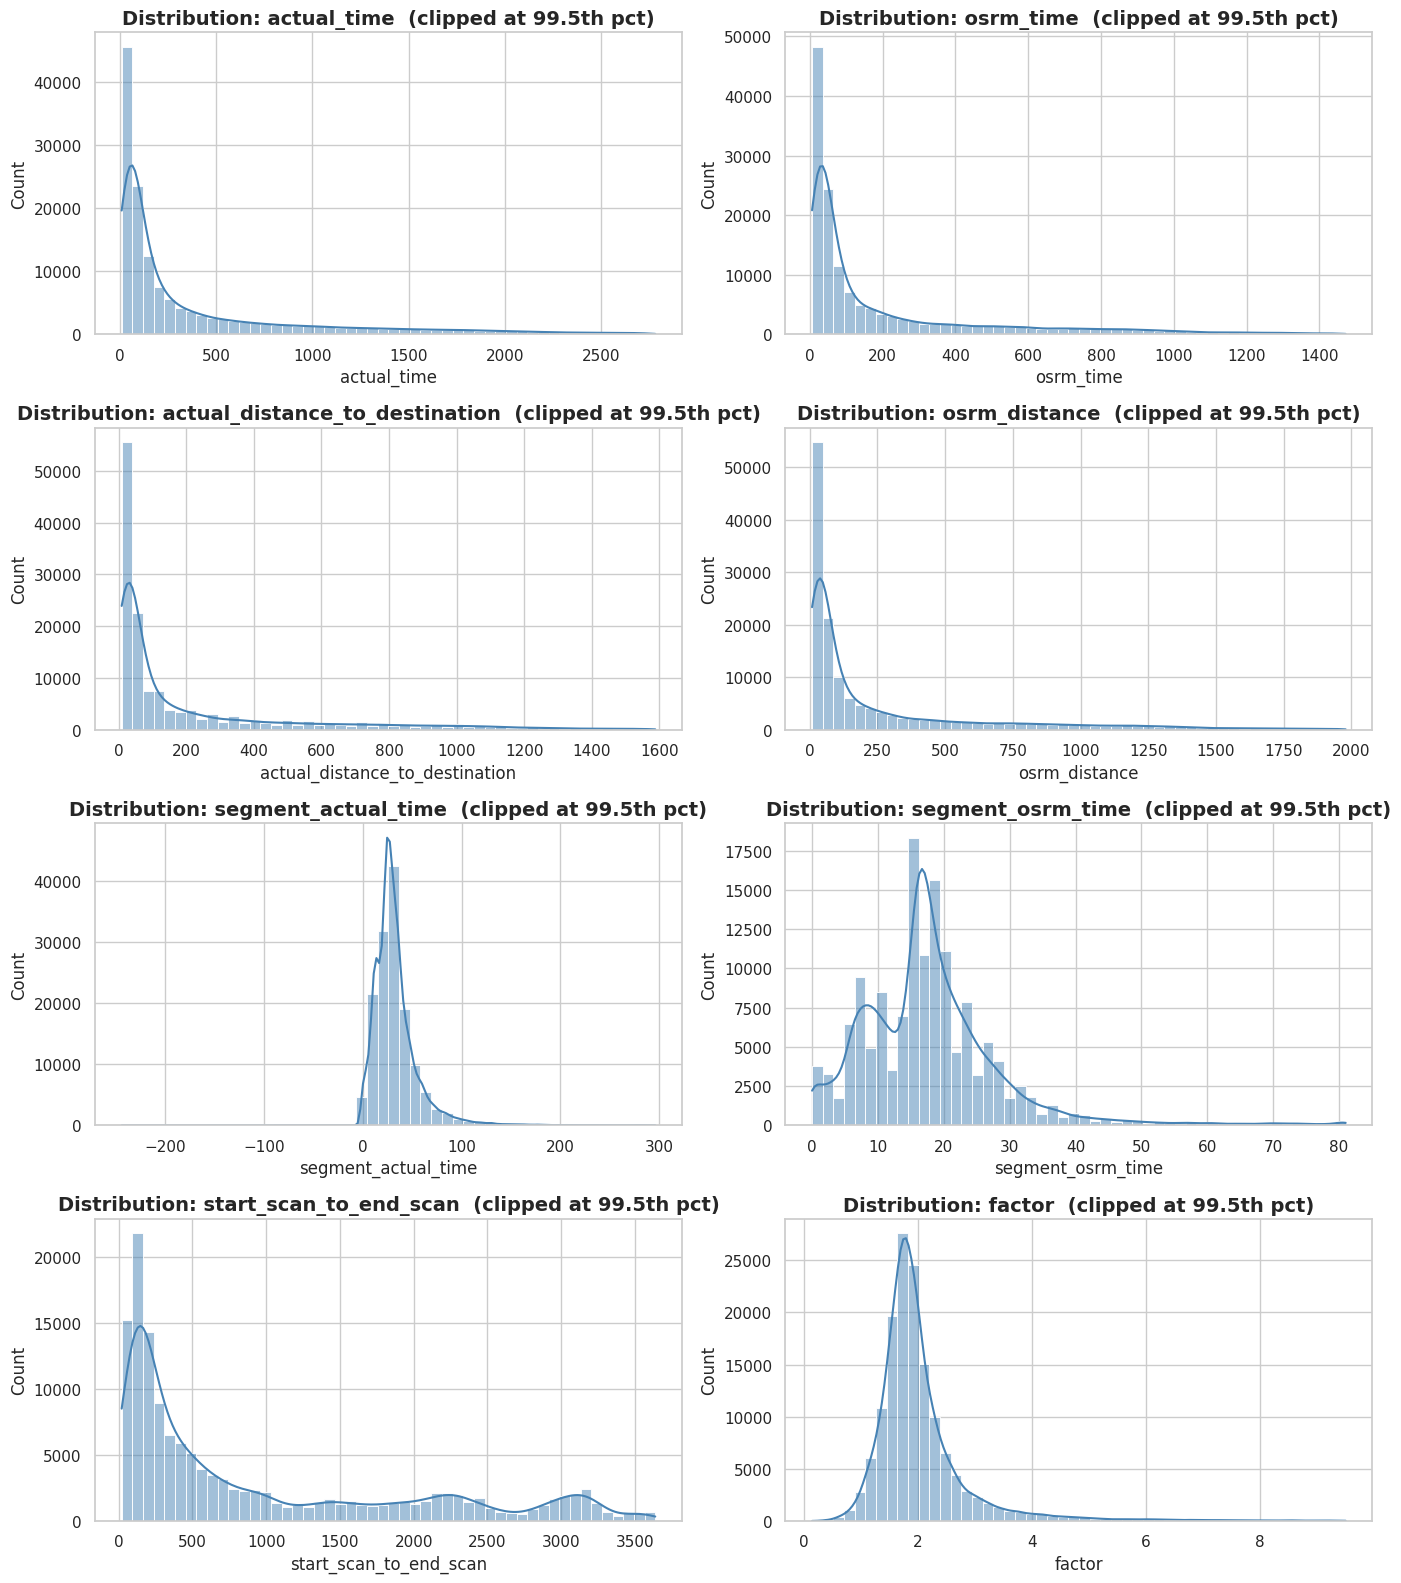

In [17]:
# ── 3.6 Distribution plots for key numeric features ──────────────────────────────────────
num_cols_to_plot = ['actual_time', 'osrm_time', 'actual_distance_to_destination',
                     'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
                     'start_scan_to_end_scan', 'factor']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols_to_plot):
    data = df[col]
    # Trim extreme outliers (>99.5th percentile) purely for visualization clarity
    clip_val = data.quantile(0.995)
    sns.histplot(data[data <= clip_val], bins=50, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f"Distribution: {col}  (clipped at 99.5th pct)")

plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


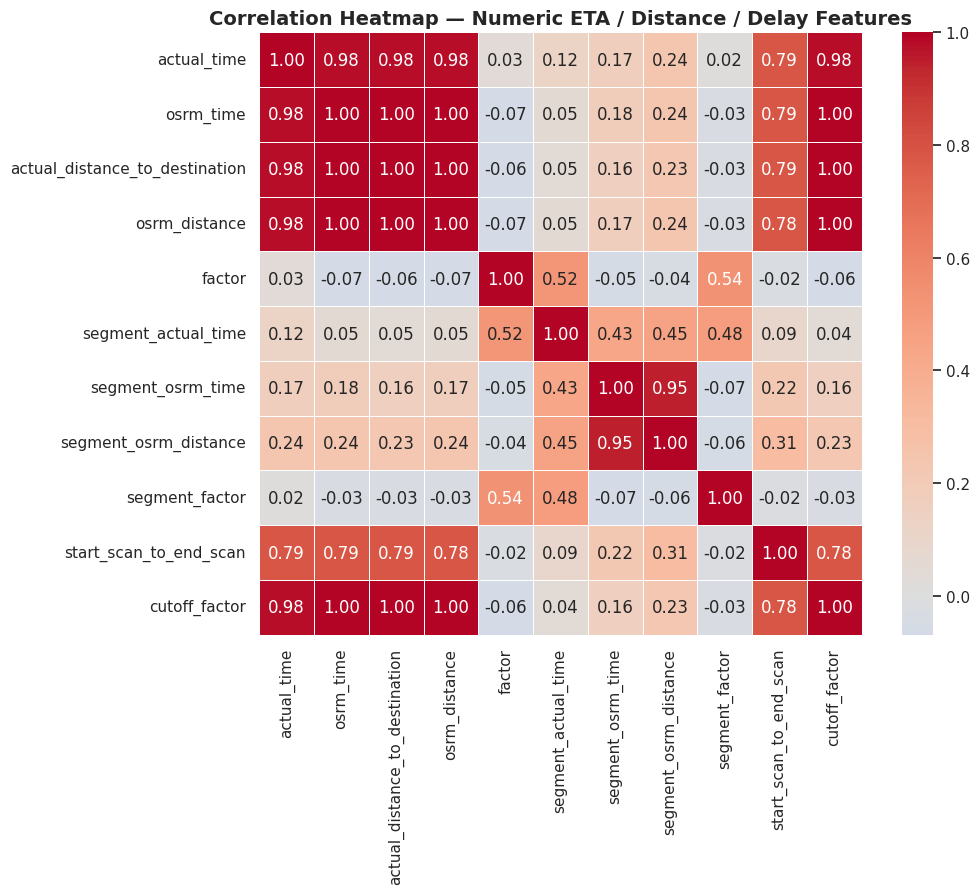

In [18]:
# ── 3.7 Correlation heatmap of numeric features ──────────────────────────────────────────
corr_cols = ['actual_time', 'osrm_time', 'actual_distance_to_destination', 'osrm_distance',
              'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
              'segment_factor', 'start_scan_to_end_scan', 'cutoff_factor']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Numeric ETA / Distance / Delay Features")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


**EDA takeaways to carry forward (will be confirmed numerically once the above cells
run):**
- `actual_time` and `osrm_time` / `osrm_distance` are highly correlated — OSRM
  distance/time is a strong *baseline* signal, but the residual (the part OSRM
  misses) is exactly what corridor-level and network-level features should explain.
- `factor` > 1 for the majority of rows indicates **systemic real-world delay**
  versus OSRM's free-flow assumption — this is the gap our graph-enhanced model
  targets.
- A small number of facilities dominate source/destination volume — these are
  natural candidates for "hub" status in the graph analysis (Sections 6–7).


---
## SECTION 4 — Feature Engineering

**Design choice:** We engineer features at **two grains**:
1. **Segment-level** (one row = one row in `df`) — delay ratios/minutes, time-of-day,
   day-of-week, weekend/peak flags, trip duration features. These feed the
   tabular ETA models in Sections 9 & 11.
2. **Corridor-level** (aggregated by `source_center -> destination_center`) — median
   delay ratio, average delay, trip volume, dominant route type. These become
   **edge attributes** for the graph in Section 5.

All engineered columns are prefixed/named descriptively so they're self-documenting
in later `df.columns` inspections.


In [19]:
# ── 4.1 Delay ratio & delay minutes (segment-level) ──────────────────────────────────────
# delay_ratio: how many times longer the actual segment took vs OSRM's estimate.
#   >1 => slower than OSRM (delay), <1 => faster than OSRM, ==1 => on par.
# Guard against division by zero (osrm_time == 0) using replace -> NaN -> fill with 1
df['segment_osrm_time_safe'] = df['segment_osrm_time'].replace(0, np.nan)
df['delay_ratio'] = (df['segment_actual_time'] / df['segment_osrm_time_safe']).fillna(1.0)

# delay_minutes: absolute extra minutes beyond OSRM's estimate (can be negative
# if the segment was completed faster than OSRM predicted).
df['delay_minutes'] = df['segment_actual_time'] - df['segment_osrm_time']

print(df[['segment_actual_time', 'segment_osrm_time', 'delay_ratio', 'delay_minutes']].describe())


       segment_actual_time  segment_osrm_time    delay_ratio  delay_minutes
count        144867.000000      144867.000000  144867.000000  144867.000000
mean             36.196111          18.507548       2.250771      17.688563
std              53.571158          14.775960       4.832571      49.010556
min            -244.000000           0.000000     -23.444444    -274.000000
25%              20.000000          11.000000       1.347826       5.000000
50%              29.000000          17.000000       1.684211      10.000000
75%              40.000000          22.000000       2.250000      19.000000
max            3051.000000        1611.000000     574.250000    2418.000000


In [20]:
# ── 4.2 Time-of-day buckets (based on od_start_time, the segment's departure time) ──────
def time_of_day_bucket(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['od_start_hour'] = df['od_start_time'].dt.hour
df['time_of_day'] = df['od_start_hour'].apply(time_of_day_bucket)

df['time_of_day'].value_counts()


,count
time_of_day,
Night,67187
Morning,37848
Evening,21825
Afternoon,18007


In [21]:
# ── 4.3 Day of week & weekend indicator ──────────────────────────────────────────────────
df['day_of_week'] = df['od_start_time'].dt.day_name()
df['day_of_week_num'] = df['od_start_time'].dt.dayofweek  # Monday=0 ... Sunday=6
df['is_weekend'] = df['day_of_week_num'].isin([5, 6]).astype(int)  # Sat/Sun

df[['day_of_week', 'is_weekend']].value_counts().sort_index()


,,count
day_of_week,is_weekend,
Friday,0,19759
Monday,0,19027
Saturday,1,21343
Sunday,1,17496
Thursday,0,22169
Tuesday,0,19742
Wednesday,0,25331


In [22]:
# ── 4.4 Peak-hour indicator ───────────────────────────────────────────────────────────────
# Defined using typical logistics peak windows: morning dispatch rush (8-11) and
# evening dispatch rush (17-21), when road congestion and hub throughput are highest.
PEAK_HOURS = set(range(8, 12)) | set(range(17, 21))
df['is_peak_hour'] = df['od_start_hour'].isin(PEAK_HOURS).astype(int)

print("Peak-hour share of segments: {:.2f}%".format(df['is_peak_hour'].mean() * 100))


Peak-hour share of segments: 25.62%


In [23]:
# ── 4.5 Trip duration features ───────────────────────────────────────────────────────────
# od_duration_min: wall-clock duration of this OD leg (minutes)
df['od_duration_min'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 60.0

# speed proxies (km per hour) -- guard divide-by-zero with safe denominators
df['actual_speed_kmph'] = df['actual_distance_to_destination'] / (df['actual_time'].replace(0, np.nan) / 60.0)
df['osrm_speed_kmph'] = df['osrm_distance'] / (df['osrm_time'].replace(0, np.nan) / 60.0)

# distance efficiency: how much longer the real route is vs OSRM's straight/road-network estimate
df['distance_efficiency'] = df['actual_distance_to_destination'] / df['osrm_distance'].replace(0, np.nan)

df[['od_duration_min', 'actual_speed_kmph', 'osrm_speed_kmph', 'distance_efficiency']].describe()


,od_duration_min,actual_speed_kmph,osrm_speed_kmph,distance_efficiency
count,144867.000000,144867.000000,144867.000000,144867.000000
mean,961.759003,32.871835,74.630450,0.817341
std,1037.012613,10.370855,11.073631,0.101470
min,20.702813,0.434947,25.040500,0.096352
25%,161.501292,26.660242,66.783659,0.770827
50%,449.236567,33.853540,78.927048,0.830672
75%,1634.950143,39.151779,83.270329,0.884273
max,7898.551955,344.421390,103.195000,1.023299


In [24]:
# ── 4.6 Corridor-level aggregations (source_center -> destination_center) ──────────────
# This table becomes the EDGE LIST for our graph in Section 5, and is also useful
# standalone for the corridor delay audit (Section 8).
corridor_agg = (
    df.groupby(['source_center', 'destination_center'])
      .agg(
          trip_volume          = ('trip_uuid', 'nunique'),
          segment_count        = ('segment_actual_time', 'count'),
          avg_actual_time      = ('segment_actual_time', 'mean'),
          avg_osrm_time        = ('segment_osrm_time', 'mean'),
          median_delay_ratio   = ('delay_ratio', 'median'),
          mean_delay_ratio     = ('delay_ratio', 'mean'),
          avg_delay_minutes    = ('delay_minutes', 'mean'),
          avg_distance_km      = ('segment_osrm_distance', 'mean'),
          dominant_route_type  = ('route_type', lambda x: x.mode().iloc[0]),
          pct_ftl              = ('route_type', lambda x: (x == 'FTL').mean()),
      )
      .reset_index()
)

# Flag corridors with significant systemic delay (median delay ratio > 1.2 == 20%+ slower than OSRM)
corridor_agg['is_high_delay_corridor'] = (corridor_agg['median_delay_ratio'] > 1.2).astype(int)

print(f"Total unique corridors: {len(corridor_agg):,}")
corridor_agg.sort_values('trip_volume', ascending=False).head(10)


Total unique corridors: 2,783


,source_center,destination_center,trip_volume,segment_count,avg_actual_time,avg_osrm_time,median_delay_ratio,mean_delay_ratio,avg_delay_minutes,avg_distance_km,dominant_route_type,pct_ftl,is_high_delay_corridor
1775,IND562132AAA,IND560300AAA,151,603,21.706468,12.832504,1.416667,1.721743,8.873964,11.344714,Carting,0.000000,1
1774,IND562132AAA,IND560099AAB,127,508,22.612205,13.736220,1.438750,1.737690,8.875984,13.418540,Carting,0.149606,1
1719,IND560099AAB,IND560300AAA,121,605,22.598347,12.644628,1.529412,1.871819,9.953719,12.114883,Carting,0.000000,1
1735,IND560300AAA,IND562132AAA,108,425,26.449412,16.378824,1.318182,1.480220,10.070588,13.285780,Carting,0.000000,1
1080,IND411033AAA,IND421302AAG,107,520,44.675000,23.740385,1.379310,1.825705,20.934615,27.515942,FTL,1.000000,1
1152,IND421302AAG,IND400072AAB,105,307,20.749186,7.426710,2.181818,2.879611,13.322476,9.432772,Carting,0.000000,1
1720,IND560099AAB,IND562132AAA,102,424,23.058962,13.599057,1.400000,1.850644,9.459906,13.266260,Carting,0.117925,1
68,IND000000ACT,IND000000ACB,100,314,21.977707,13.649682,1.333333,2.132924,8.328025,14.386601,Carting,0.359873,1
1010,IND400072AAD,IND421302AAG,99,282,28.195035,7.301418,2.200000,4.794052,20.893617,9.188476,Carting,0.000000,1
38,IND000000ACB,IND131028AAB,92,741,26.493927,21.441296,0.947368,1.624225,5.052632,16.701939,Carting,0.000000,0


In [25]:
# ── 4.7 Final feature summary ────────────────────────────────────────────────────────────
new_features = ['delay_ratio', 'delay_minutes', 'od_start_hour', 'time_of_day',
                'day_of_week', 'day_of_week_num', 'is_weekend', 'is_peak_hour',
                'od_duration_min', 'actual_speed_kmph', 'osrm_speed_kmph', 'distance_efficiency']
print("Newly engineered segment-level features:")
for f in new_features:
    print(" -", f)

print(f"\nDataframe shape after feature engineering: {df.shape}")


Newly engineered segment-level features:
 - delay_ratio
 - delay_minutes
 - od_start_hour
 - time_of_day
 - day_of_week
 - day_of_week_num
 - is_weekend
 - is_peak_hour
 - od_duration_min
 - actual_speed_kmph
 - osrm_speed_kmph
 - distance_efficiency

Dataframe shape after feature engineering: (144867, 38)


---
## SECTION 5 — Graph Construction

**Design choice — why a directed graph at the facility level:**
Delhivery's network is fundamentally a **hub-and-spoke transportation graph**. Modeling
`source_center -> destination_center` as a directed edge lets us apply decades of
network-science tooling (centrality, PageRank, clustering) to answer operational
questions like *"which hub, if delayed, has the largest downstream ripple effect?"*

- **Nodes** = facility codes (`source_center`, `destination_center`), with the
  human-readable facility name stored as a node attribute.
- **Edges** = corridors, carrying `median_delay_ratio`, `avg_delay_minutes`,
  `trip_volume`, and `dominant_route_type` as attributes (from `corridor_agg`,
  Section 4.6).
- **Directed**, because a delay on A→B does not imply the same delay on B→A
  (asymmetric traffic, loading patterns, road conditions).
- We **do not multi-edge** — each (source, destination) pair collapses to a single
  edge with aggregated attributes, since centrality/PageRank algorithms expect
  simple directed graphs.


In [26]:
# ── 5.1 Build a node attribute lookup (facility code -> facility name) ──────────────────
node_names = {}
for _, row in df[['source_center', 'source_name']].drop_duplicates().iterrows():
    node_names[row['source_center']] = row['source_name']
for _, row in df[['destination_center', 'destination_name']].drop_duplicates().iterrows():
    node_names.setdefault(row['destination_center'], row['destination_name'])

print(f"Total named facilities: {len(node_names):,}")


Total named facilities: 1,657


In [27]:
# ── 5.2 Build the directed corridor graph ────────────────────────────────────────────────
G = nx.DiGraph()

# Add nodes with name attribute
for code_, name in node_names.items():
    G.add_node(code_, name=name)

# Add edges from corridor_agg with attributes
for _, row in corridor_agg.iterrows():
    G.add_edge(
        row['source_center'],
        row['destination_center'],
        median_delay_ratio = row['median_delay_ratio'],
        mean_delay_ratio   = row['mean_delay_ratio'],
        avg_delay_minutes  = row['avg_delay_minutes'],
        trip_volume        = row['trip_volume'],
        avg_distance_km    = row['avg_distance_km'],
        dominant_route_type= row['dominant_route_type'],
        pct_ftl            = row['pct_ftl'],
        is_high_delay      = row['is_high_delay_corridor'],
    )

print(f"Graph nodes (facilities) : {G.number_of_nodes():,}")
print(f"Graph edges (corridors)  : {G.number_of_edges():,}")
print(f"Is the graph weakly connected? {nx.is_weakly_connected(G)}")
print(f"Number of weakly connected components: {nx.number_weakly_connected_components(G)}")


Graph nodes (facilities) : 1,657
Graph edges (corridors)  : 2,783
Is the graph weakly connected? False
Number of weakly connected components: 64


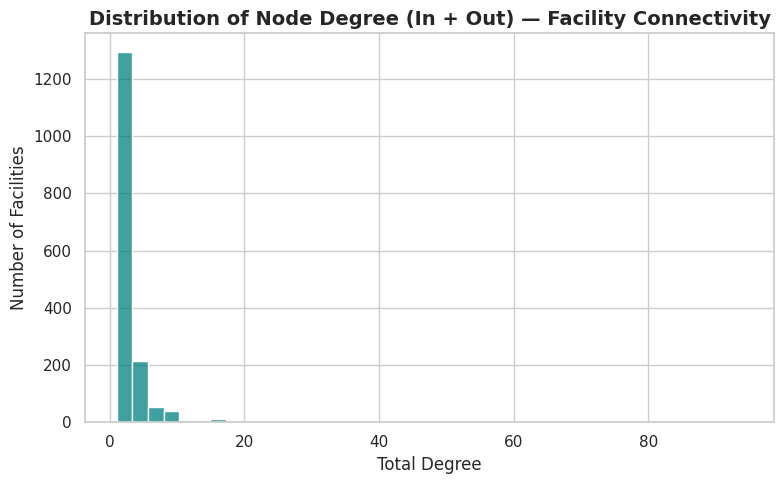

In [28]:
# ── 5.3 Quick visual sanity check: degree distribution ───────────────────────────────────
degrees = [d for _, d in G.degree()]

plt.figure(figsize=(8, 5))
sns.histplot(degrees, bins=40, color='teal')
plt.title("Distribution of Node Degree (In + Out) — Facility Connectivity")
plt.xlabel("Total Degree")
plt.ylabel("Number of Facilities")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


In [29]:
# ── 5.4 Use the largest weakly-connected component for downstream centrality metrics ────
# Disconnected facilities (one-off corridors with no path back into the main network)
# would otherwise return undefined/zero values for closeness & eigenvector centrality.
largest_wcc_nodes = max(nx.weakly_connected_components(G), key=len)
G_main = G.subgraph(largest_wcc_nodes).copy()

print(f"Main component nodes: {G_main.number_of_nodes():,} "
      f"({G_main.number_of_nodes()/G.number_of_nodes()*100:.1f}% of all facilities)")
print(f"Main component edges: {G_main.number_of_edges():,} "
      f"({G_main.number_of_edges()/G.number_of_edges()*100:.1f}% of all corridors)")


Main component nodes: 1,353 (81.7% of all facilities)
Main component edges: 2,463 (88.5% of all corridors)


---
## SECTION 6 — Graph Analytics: Centrality, PageRank & Clustering

**Design choice — what each metric tells an operations leader:**

| Metric | Operational meaning |
|---|---|
| **Degree Centrality** (in/out/total) | How many direct corridors a facility serves — raw connectivity / workload |
| **Betweenness Centrality** | How often a facility sits on the *shortest path* between other facility pairs — a structural bottleneck if removed |
| **Closeness Centrality** | How quickly a facility can reach (or be reached by) the rest of the network — proxy for network-wide reach |
| **Eigenvector Centrality** | Influence based on being connected to *other well-connected* facilities — "hub of hubs" |
| **PageRank** | Like eigenvector centrality but tolerant of cycles/directionality — good general-purpose hub-importance score |
| **Clustering Coefficient** | How tightly a facility's neighbors are interconnected — local redundancy (low = single point of failure) |

All metrics are computed on `G_main` (the largest connected component) and merged
into one ranking table.


In [30]:
# ── 6.1 Degree centrality (in, out, total) ───────────────────────────────────────────────
in_degree_centrality  = nx.in_degree_centrality(G_main)
out_degree_centrality = nx.out_degree_centrality(G_main)
degree_centrality     = nx.degree_centrality(G_main)

in_degree_raw  = dict(G_main.in_degree())
out_degree_raw = dict(G_main.out_degree())


In [31]:
# ── 6.2 Betweenness centrality ───────────────────────────────────────────────────────────
# NOTE: exact betweenness is O(V*E); for very large graphs you may set k=<sample size>
# for an approximation. With ~1,500 facilities this typically completes in a few minutes.
betweenness_centrality = nx.betweenness_centrality(G_main, weight=None, normalized=True)


In [32]:
# ── 6.3 Closeness centrality ─────────────────────────────────────────────────────────────
closeness_centrality = nx.closeness_centrality(G_main)


In [33]:
# ── 6.4 Eigenvector centrality ───────────────────────────────────────────────────────────
# max_iter raised since directed graphs with skewed degree distributions can need
# more iterations to converge.
try:
    eigenvector_centrality = nx.eigenvector_centrality(G_main, max_iter=1000, weight=None)
except nx.PowerIterationFailedConvergence:
    eigenvector_centrality = nx.eigenvector_centrality_numpy(G_main, weight=None)


In [34]:
# ── 6.5 PageRank ──────────────────────────────────────────────────────────────────────────
# Weighted by trip_volume so high-traffic corridors transmit more "importance".
pagerank = nx.pagerank(G_main, weight='trip_volume')


In [35]:
# ── 6.6 Clustering coefficient ───────────────────────────────────────────────────────────
# Computed on the undirected projection — clustering coefficient is conventionally
# defined for undirected graphs (triangle density around a node).
clustering_coefficient = nx.clustering(G_main.to_undirected())


In [36]:
# ── 6.7 Assemble the master centrality ranking table ─────────────────────────────────────
centrality_df = pd.DataFrame({
    'facility_code'        : list(G_main.nodes()),
})
centrality_df['facility_name'] = centrality_df['facility_code'].map(lambda c: G_main.nodes[c].get('name', c))
centrality_df['in_degree']             = centrality_df['facility_code'].map(in_degree_raw)
centrality_df['out_degree']            = centrality_df['facility_code'].map(out_degree_raw)
centrality_df['degree_centrality']     = centrality_df['facility_code'].map(degree_centrality)
centrality_df['in_degree_centrality']  = centrality_df['facility_code'].map(in_degree_centrality)
centrality_df['out_degree_centrality'] = centrality_df['facility_code'].map(out_degree_centrality)
centrality_df['betweenness_centrality']= centrality_df['facility_code'].map(betweenness_centrality)
centrality_df['closeness_centrality']  = centrality_df['facility_code'].map(closeness_centrality)
centrality_df['eigenvector_centrality']= centrality_df['facility_code'].map(eigenvector_centrality)
centrality_df['pagerank']              = centrality_df['facility_code'].map(pagerank)
centrality_df['clustering_coefficient']= centrality_df['facility_code'].map(clustering_coefficient)

centrality_df = centrality_df.sort_values('pagerank', ascending=False).reset_index(drop=True)
centrality_df.head(15)


,facility_code,facility_name,in_degree,out_degree,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,pagerank,clustering_coefficient
0,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),45,49,0.069527,0.033284,0.036243,0.330444,0.225327,0.429184,0.022431,0.037158
1,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),36,35,0.052515,0.026627,0.025888,0.187473,0.210061,0.309725,0.015267,0.053571
2,IND501359AAE,Hyderabad_Shamshbd_H (Telangana),30,27,0.042160,0.022189,0.019970,0.138991,0.204198,0.238614,0.012964,0.042683
3,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),32,29,0.045118,0.023669,0.021450,0.082643,0.188074,0.131890,0.011698,0.034330
4,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),24,22,0.034024,0.017751,0.016272,0.136031,0.206364,0.199065,0.010080,0.039216
5,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),29,29,0.042899,0.021450,0.021450,0.104470,0.204609,0.267157,0.009555,0.061562
6,IND411033AAA,Pune_Tathawde_H (Maharashtra),23,20,0.031805,0.017012,0.014793,0.064901,0.198181,0.201058,0.008580,0.061576
7,IND131028AAB,Sonipat_Kundli_H (Haryana),20,20,0.029586,0.014793,0.014793,0.071778,0.191140,0.132150,0.007480,0.038710
8,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),16,13,0.021450,0.011834,0.009615,0.060558,0.186008,0.114989,0.007065,0.034632
9,IND560099AAB,Bengaluru_Bomsndra_HB (Karnataka),11,18,0.021450,0.008136,0.013314,0.005215,0.169559,0.097224,0.006402,0.136842


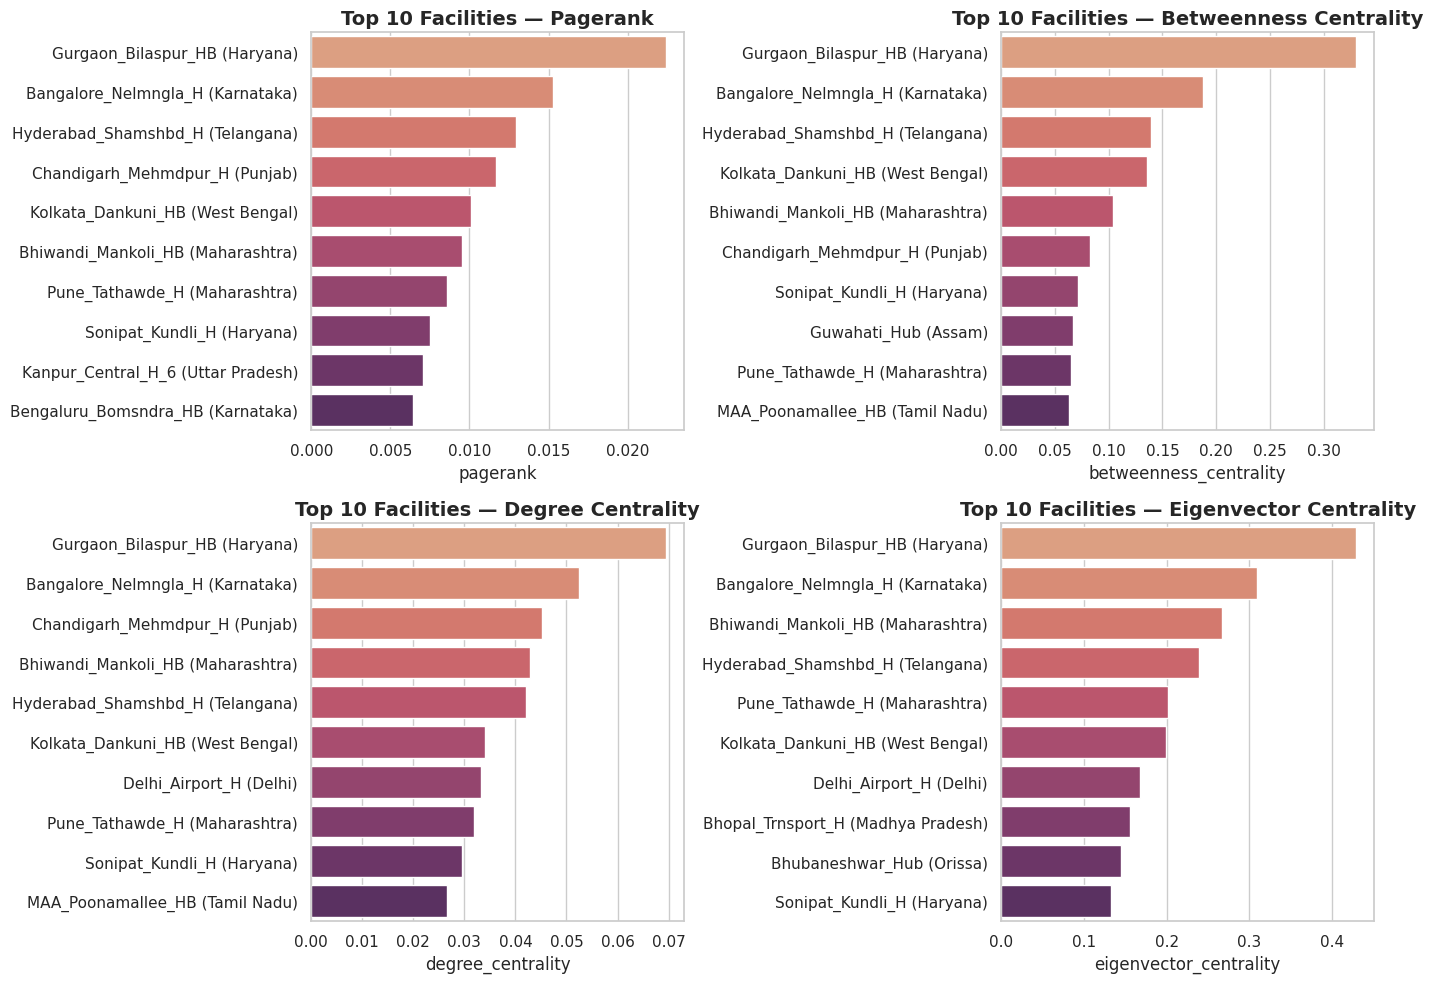

In [37]:
# ── 6.8 Visualize top facilities by each centrality metric ───────────────────────────────
metrics_to_show = ['pagerank', 'betweenness_centrality', 'degree_centrality', 'eigenvector_centrality']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, metric in zip(axes, metrics_to_show):
    top10 = centrality_df.nlargest(10, metric)
    sns.barplot(x=metric, y='facility_name', data=top10, ax=ax, palette='flare')
    ax.set_title(f"Top 10 Facilities — {metric.replace('_', ' ').title()}")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 7 — Bottleneck Hub Detection

**Design choice — composite "Structural Risk Score":**
No single centrality metric fully captures "bottleneck-ness". A facility can be
structurally critical (high betweenness) yet have low *delay* — or vice versa,
a peripheral facility may chronically run late but not matter to the wider network.
The structural risk score is designed to prioritize facilities that combine
network criticality with operational underperformance. Facilities with high
scores represent the highest leverage intervention points because improvements
at these hubs propagate benefits across multiple downstream corridors.
We therefore define:

```
structural_risk_score =
      0.35 * normalized(betweenness_centrality)
    + 0.25 * normalized(pagerank)
    + 0.20 * normalized(avg_outbound_delay_ratio)
    + 0.20 * normalized(total_segment_volume)
```

Weights reflect a judgment call: **structural importance (betweenness + PageRank,
60%)** matters slightly more than **raw delay + volume (40%)**, because a high-delay
facility with low network importance is a local problem, while a structurally
critical facility with even moderate delay propagates network-wide. All four
components are min-max normalized to [0, 1] before weighting so no single metric
dominates due to scale.

**SLA breach contribution** is defined as the share of all segments where
`segment_factor > 1.0` (i.e., actual time exceeded OSRM's estimate — our proxy for
an SLA/ETA breach) that originate from or terminate at that facility.


In [38]:
# ── 7.1 Per-facility delay & volume aggregates ───────────────────────────────────────────
# Outbound (as source) delay/volume
outbound = df.groupby('source_center').agg(
    outbound_segment_count = ('segment_actual_time', 'count'),
    avg_outbound_delay_ratio = ('delay_ratio', 'mean'),
    outbound_sla_breaches = ('segment_factor', lambda x: (x > 1.0).sum()),
).reset_index().rename(columns={'source_center': 'facility_code'})

# Inbound (as destination) delay/volume
inbound = df.groupby('destination_center').agg(
    inbound_segment_count = ('segment_actual_time', 'count'),
    avg_inbound_delay_ratio = ('delay_ratio', 'mean'),
    inbound_sla_breaches = ('segment_factor', lambda x: (x > 1.0).sum()),
).reset_index().rename(columns={'destination_center': 'facility_code'})

facility_stats = outbound.merge(inbound, on='facility_code', how='outer').fillna(0)
facility_stats['total_segment_volume'] = facility_stats['outbound_segment_count'] + facility_stats['inbound_segment_count']
facility_stats['total_sla_breaches'] = facility_stats['outbound_sla_breaches'] + facility_stats['inbound_sla_breaches']

total_sla_breaches_overall = (df['segment_factor'] > 1.0).sum()
facility_stats['sla_breach_contribution_pct'] = (
    facility_stats['total_sla_breaches'] / total_sla_breaches_overall * 100
)

facility_stats.head()


,facility_code,outbound_segment_count,avg_outbound_delay_ratio,outbound_sla_breaches,inbound_segment_count,avg_inbound_delay_ratio,inbound_sla_breaches,total_segment_volume,total_sla_breaches,sla_breach_contribution_pct
0,IND000000AAL,37.0,2.957762,35.0,37.0,2.758620,32.0,74.0,67.0,0.051797
1,IND000000AAQ,4.0,5.416667,4.0,0.0,0.000000,0.0,4.0,4.0,0.003092
2,IND000000AAS,18.0,2.580453,18.0,24.0,3.053000,24.0,42.0,42.0,0.032470
3,IND000000AAZ,6.0,2.951609,5.0,6.0,3.758351,6.0,12.0,11.0,0.008504
4,IND000000ABA,13.0,1.550218,5.0,47.0,1.155945,25.0,60.0,30.0,0.023193


In [39]:
# ── 7.2 Merge centrality metrics with delay/volume stats ─────────────────────────────────
bottleneck_df = centrality_df.merge(facility_stats, on='facility_code', how='left').fillna(0)

# ── 7.3 Min-max normalize the 4 components of the structural risk score ────────────────
def min_max_norm(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

bottleneck_df['norm_betweenness'] = min_max_norm(bottleneck_df['betweenness_centrality'])
bottleneck_df['norm_pagerank']    = min_max_norm(bottleneck_df['pagerank'])
bottleneck_df['norm_delay']       = min_max_norm(bottleneck_df['avg_outbound_delay_ratio'])
bottleneck_df['norm_volume']      = min_max_norm(bottleneck_df['total_segment_volume'])

# ── 7.4 Composite structural risk score ──────────────────────────────────────────────────
bottleneck_df['structural_risk_score'] = (
      0.35 * bottleneck_df['norm_betweenness']
    + 0.25 * bottleneck_df['norm_pagerank']
    + 0.20 * bottleneck_df['norm_delay']
    + 0.20 * bottleneck_df['norm_volume']
)

top20_bottlenecks = bottleneck_df.sort_values('structural_risk_score', ascending=False).head(20)
top20_bottlenecks[['facility_name', 'structural_risk_score', 'betweenness_centrality',
                    'pagerank', 'avg_outbound_delay_ratio', 'total_segment_volume',
                    'sla_breach_contribution_pct']].reset_index(drop=True)


,facility_name,structural_risk_score,betweenness_centrality,pagerank,avg_outbound_delay_ratio,total_segment_volume,sla_breach_contribution_pct
0,Gurgaon_Bilaspur_HB (Haryana),0.807015,0.330444,0.022431,1.917950,38539.0,25.917851
1,Bangalore_Nelmngla_H (Karnataka),0.483726,0.187473,0.015267,1.786598,20994.0,14.609860
2,Hyderabad_Shamshbd_H (Telangana),0.342443,0.138991,0.012964,2.013046,8482.0,6.058708
3,Kolkata_Dankuni_HB (West Bengal),0.303208,0.136031,0.010080,2.370424,7504.0,5.335096
4,Bhiwandi_Mankoli_HB (Maharashtra),0.299824,0.104470,0.009555,2.154687,14580.0,10.561186
5,Chandigarh_Mehmdpur_H (Punjab),0.251779,0.082643,0.011698,1.902173,5324.0,3.710060
6,Pune_Tathawde_H (Maharashtra),0.210959,0.064901,0.008580,1.989206,7756.0,5.362927
7,Bikramgang_Dehrird_D (Bihar),0.206336,0.001209,0.000577,54.680181,19.0,0.013143
8,Sonipat_Kundli_H (Haryana),0.188260,0.071778,0.007480,1.813194,4478.0,2.574391
9,Delhi_Airport_H (Delhi),0.172692,0.062015,0.006296,2.163998,5782.0,4.117479


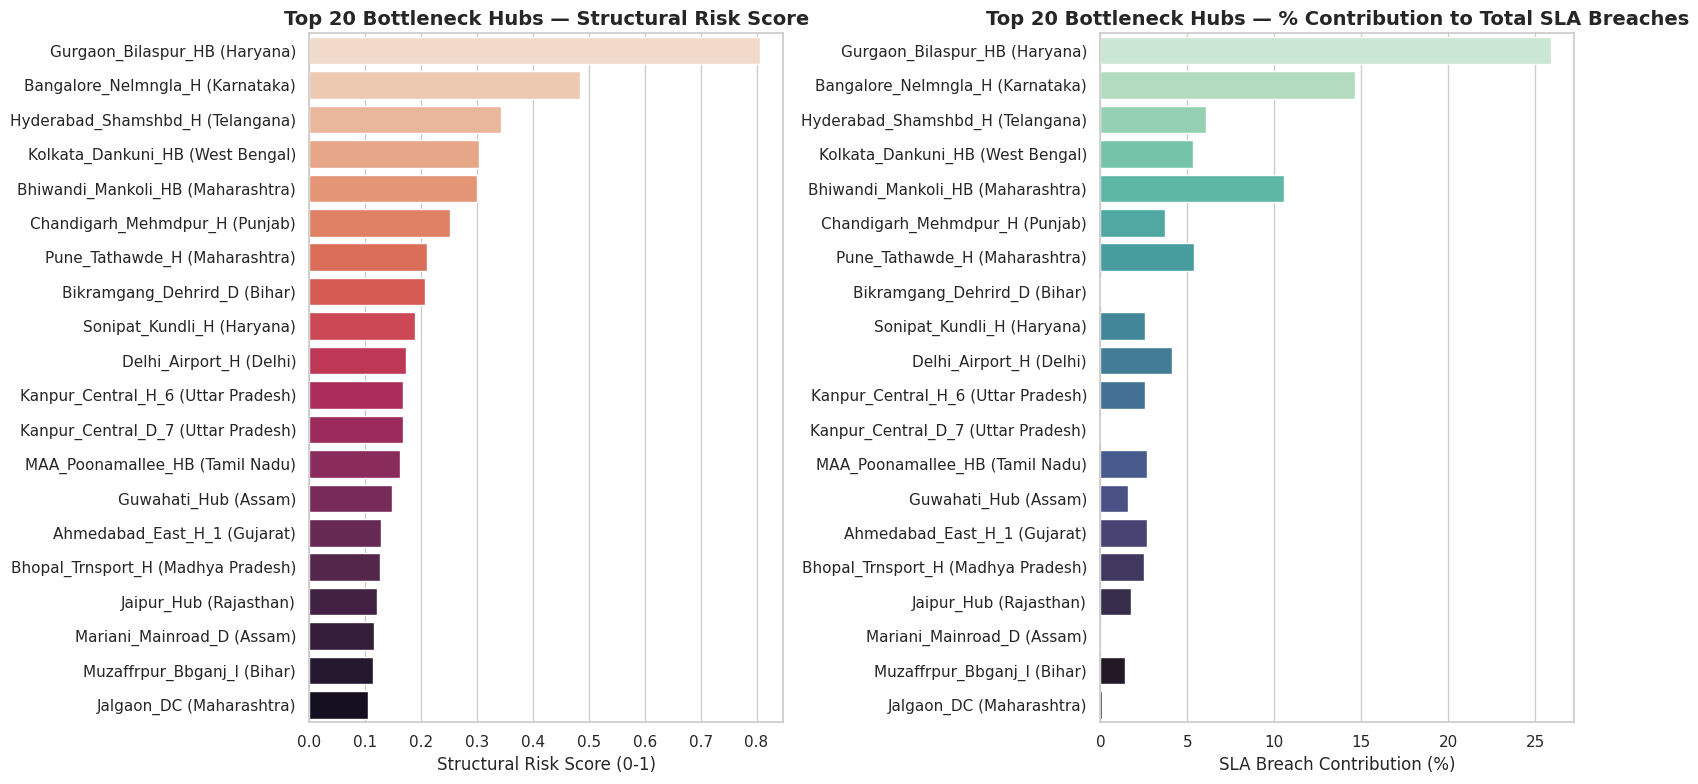

In [40]:
# ── 7.5 Business-friendly visualization: Top 20 bottleneck hubs ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='structural_risk_score', y='facility_name', data=top20_bottlenecks,
            palette='rocket_r', ax=axes[0])
axes[0].set_title("Top 20 Bottleneck Hubs — Structural Risk Score")
axes[0].set_xlabel("Structural Risk Score (0-1)")
axes[0].set_ylabel("")

sns.barplot(x='sla_breach_contribution_pct', y='facility_name', data=top20_bottlenecks,
            palette='mako_r', ax=axes[1])
axes[1].set_title("Top 20 Bottleneck Hubs — % Contribution to Total SLA Breaches")
axes[1].set_xlabel("SLA Breach Contribution (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


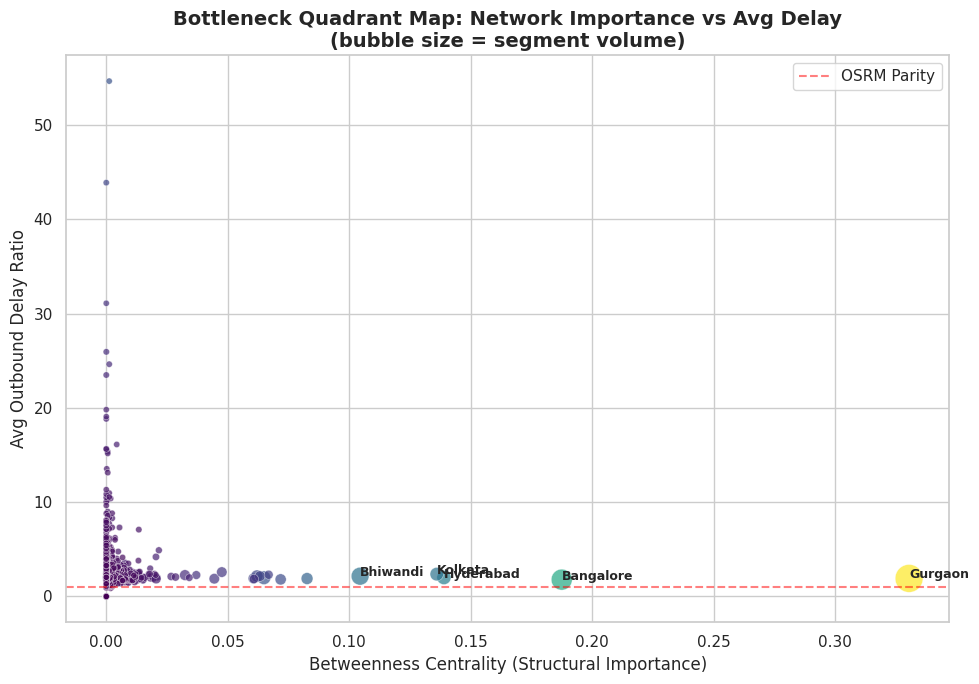

In [41]:
# ── 7.6 Scatter: structural importance vs delay — quadrant view for prioritization ──────
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=bottleneck_df, x='betweenness_centrality', y='avg_outbound_delay_ratio',
    size='total_segment_volume', sizes=(20, 400), hue='structural_risk_score',
    palette='viridis', legend=False, alpha=0.7
)
# Annotate top 5 risk hubs
for _, row in top20_bottlenecks.head(5).iterrows():
    plt.annotate(row['facility_name'].split('_')[0], (row['betweenness_centrality'], row['avg_outbound_delay_ratio']),
                  fontsize=9, fontweight='bold')

plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='OSRM Parity')
plt.title("Bottleneck Quadrant Map: Network Importance vs Avg Delay\n(bubble size = segment volume)")
plt.xlabel("Betweenness Centrality (Structural Importance)")
plt.ylabel("Avg Outbound Delay Ratio")
plt.legend()
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 8 — Corridor Delay Audit

**Design choice:** We re-use `corridor_agg` (Section 4.6) — already containing
`median_delay_ratio`, `is_high_delay_corridor` (>20% over OSRM), `dominant_route_type`,
and `trip_volume`. We rank worst corridors by *volume-weighted* delay (a corridor
that is 50% late on 2 trips matters less than one that is 25% late on 2,000 trips),
then break down high-delay corridors by route type.


In [42]:
# ── 8.1 Worst corridors by volume-weighted delay impact ──────────────────────────────────
# "delay_impact" approximates total extra minutes spent on a corridor across all its trips
corridor_agg['avg_extra_minutes_per_trip'] = corridor_agg['avg_actual_time'] - corridor_agg['avg_osrm_time']
corridor_agg['total_delay_impact_minutes'] = corridor_agg['avg_extra_minutes_per_trip'] * corridor_agg['trip_volume']

# Map facility codes to names for readability
corridor_agg['source_name'] = corridor_agg['source_center'].map(node_names)
corridor_agg['destination_name'] = corridor_agg['destination_center'].map(node_names)
corridor_agg['corridor_label'] = corridor_agg['source_name'].fillna('') + ' -> ' + corridor_agg['destination_name'].fillna('')

worst_corridors_by_impact = corridor_agg[corridor_agg['total_delay_impact_minutes'] > 0] \
    .sort_values('total_delay_impact_minutes', ascending=False).head(20)

worst_corridors_by_impact[['corridor_label', 'median_delay_ratio', 'trip_volume',
                             'avg_extra_minutes_per_trip', 'total_delay_impact_minutes',
                             'dominant_route_type']].reset_index(drop=True)


,corridor_label,median_delay_ratio,trip_volume,avg_extra_minutes_per_trip,total_delay_impact_minutes,dominant_route_type
0,Shirpur_KrantiNgr_D (Maharashtra) -> Dhule_MID...,21.185587,14,667.000000,9338.000000,FTL
1,HazratJandaha_HajiprRD_D (Bihar) -> Muzaffrpur...,11.357466,14,492.375000,6893.250000,FTL
2,Benipatti_WardNo1_D (Bihar) -> Muzaffrpur_Bbga...,9.953846,15,452.631579,6789.473684,FTL
3,Simlapal_Central_D_1 (West Bengal) -> Hura_Cen...,14.207738,8,687.800000,5502.400000,FTL
4,Helencha_ColnyDPP_D (West Bengal) -> Kolkata_D...,15.351351,5,1059.800000,5299.000000,FTL
5,Midnapore_Talkui_D (West Bengal) -> Kolkata_Da...,7.364130,13,393.350000,5113.550000,FTL
6,Ashokngr_Bypassrd_D (Madhya Pradesh) -> Guna_R...,2.027027,17,277.800000,4722.600000,FTL
7,Rishikesh_DC (Uttarakhand) -> Haridwar (Uttara...,7.880000,17,266.352941,4528.000000,FTL
8,Jhanjharpur_Nagar_D (Bihar) -> Muzaffrpur_Bbga...,3.968750,18,218.673913,3936.130435,FTL
9,Chamba_Bangotu_D (Himachal Pradesh) -> Pathank...,1.200000,13,293.948718,3821.333333,FTL


In [43]:
# ── 8.2 Corridors with median delay ratio > 20% (median_delay_ratio > 1.2) ───────────────
high_delay_corridors = corridor_agg[corridor_agg['is_high_delay_corridor'] == 1] \
    .sort_values('trip_volume', ascending=False)

print(f"Corridors with median delay >20% over OSRM: {len(high_delay_corridors):,} "
      f"of {len(corridor_agg):,} total corridors "
      f"({len(high_delay_corridors)/len(corridor_agg)*100:.1f}%)")

high_delay_corridors[['corridor_label', 'median_delay_ratio', 'trip_volume', 'dominant_route_type']].head(15)


Corridors with median delay >20% over OSRM: 2,598 of 2,783 total corridors (93.4%)


,corridor_label,median_delay_ratio,trip_volume,dominant_route_type
1775,Bangalore_Nelmngla_H (Karnataka) -> Bengaluru_...,1.416667,151,Carting
1774,Bangalore_Nelmngla_H (Karnataka) -> Bengaluru_...,1.438750,127,Carting
1719,Bengaluru_Bomsndra_HB (Karnataka) -> Bengaluru...,1.529412,121,Carting
1735,Bengaluru_KGAirprt_HB (Karnataka) -> Bangalore...,1.318182,108,Carting
1080,Pune_Tathawde_H (Maharashtra) -> Bhiwandi_Mank...,1.379310,107,FTL
1152,Bhiwandi_Mankoli_HB (Maharashtra) -> Mumbai Hu...,2.181818,105,Carting
1720,Bengaluru_Bomsndra_HB (Karnataka) -> Bangalore...,1.400000,102,Carting
68,Delhi_Gateway_HB (Delhi) -> Gurgaon_Bilaspur_H...,1.333333,100,Carting
1010,Mumbai_Chndivli_PC (Maharashtra) -> Bhiwandi_M...,2.200000,99,Carting
1734,Bengaluru_KGAirprt_HB (Karnataka) -> Bengaluru...,1.677083,86,Carting


In [44]:
# ── 8.3 Route-type specific bottleneck comparison ────────────────────────────────────────
route_type_delay = df.groupby('route_type').agg(
    avg_delay_ratio   = ('delay_ratio', 'mean'),
    median_delay_ratio= ('delay_ratio', 'median'),
    pct_sla_breach    = ('segment_factor', lambda x: (x > 1.0).mean() * 100),
    avg_delay_minutes = ('delay_minutes', 'mean'),
).reset_index()

route_type_delay


,route_type,avg_delay_ratio,median_delay_ratio,pct_sla_breach,avg_delay_minutes
0,Carting,2.670569,1.777778,85.274404,13.956025
1,FTL,2.060345,1.652174,91.110777,19.381688


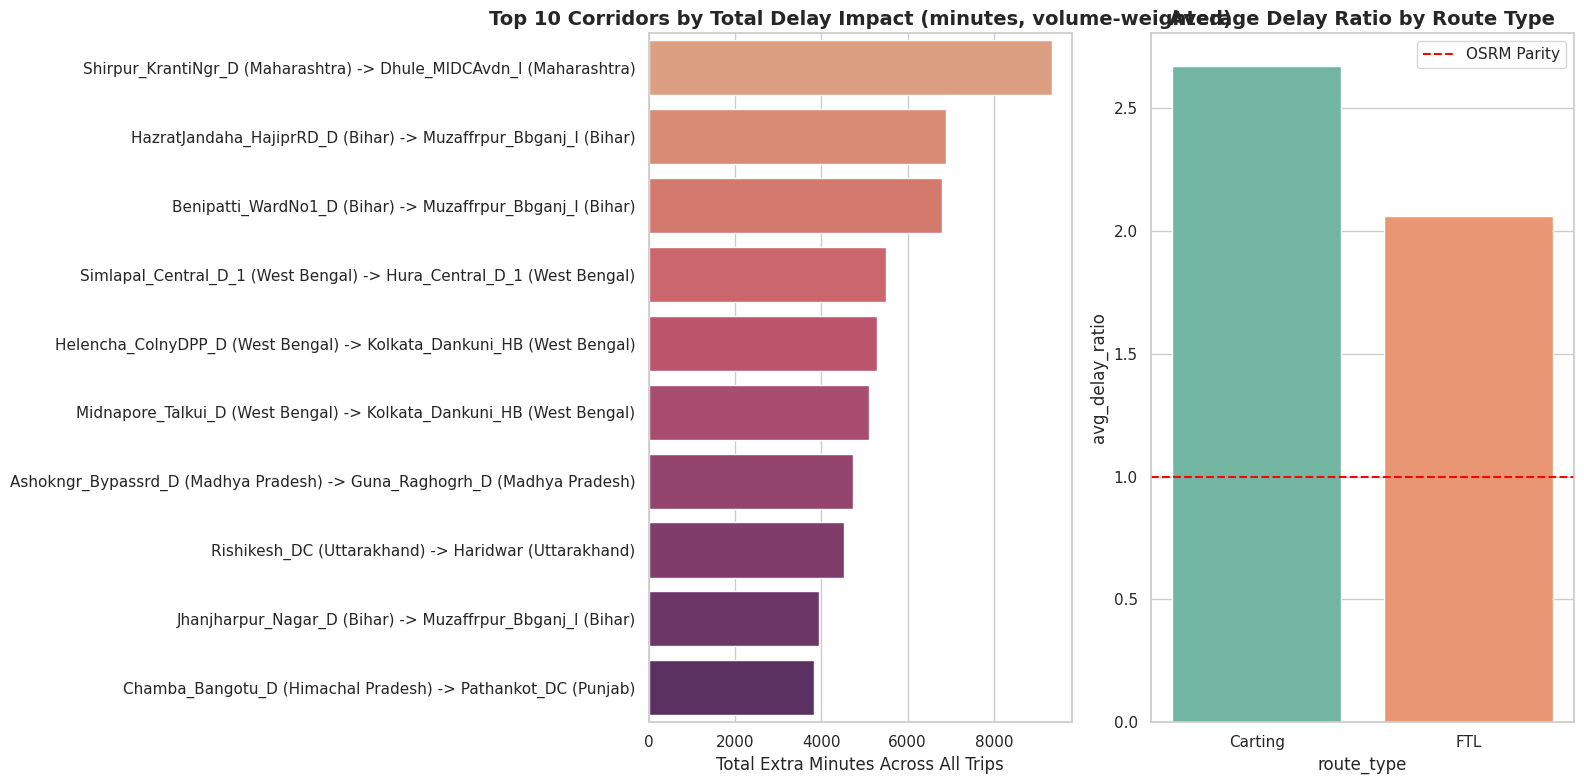

In [45]:
# ── 8.4 Visualize: worst corridors + route-type comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top10_corridors = worst_corridors_by_impact.head(10)
sns.barplot(x='total_delay_impact_minutes', y='corridor_label', data=top10_corridors,
            palette='flare', ax=axes[0])
axes[0].set_title("Top 10 Corridors by Total Delay Impact (minutes, volume-weighted)")
axes[0].set_xlabel("Total Extra Minutes Across All Trips")
axes[0].set_ylabel("")

sns.barplot(x='route_type', y='avg_delay_ratio', data=route_type_delay, ax=axes[1], palette='Set2')
axes[1].axhline(1.0, color='red', linestyle='--', label='OSRM Parity')
axes[1].set_title("Average Delay Ratio by Route Type")
axes[1].legend()

plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


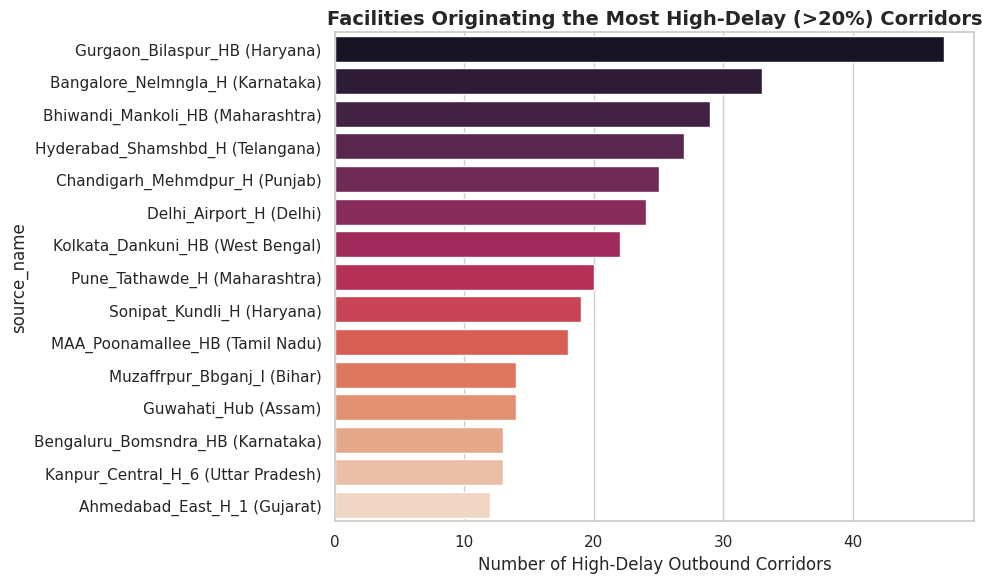

In [46]:
# ── 8.5 Heatmap: high-delay corridor concentration by source facility ───────────────────
# Which SOURCE facilities have the most high-delay outbound corridors?
high_delay_by_source = high_delay_corridors['source_name'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=high_delay_by_source.values, y=high_delay_by_source.index, palette='rocket')
plt.title("Facilities Originating the Most High-Delay (>20%) Corridors")
plt.xlabel("Number of High-Delay Outbound Corridors")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 9 — Baseline ETA Prediction Model

**Target:** `actual_time` (trip-level actual transit time, minutes).

**Design choice — feature set:** We use all *non-graph* features available at
prediction time: OSRM's own estimate (`osrm_time`, `osrm_distance`), distance,
cutoff factors, and our engineered temporal/operational features (time-of-day,
day-of-week, weekend, peak-hour, route type, distance efficiency). Categorical
features (`route_type`, `time_of_day`, `day_of_week`) are label-encoded for
tree-based models (which handle ordinal-encoded categoricals natively — no need
for one-hot here).

**Why Random Forest *and* XGBoost:** RF gives a robust, low-variance baseline and
is a useful sanity check; XGBoost typically extracts more signal from
non-linear interactions and will be our baseline-to-beat in Section 11 once graph
embeddings are added.

**Business metric:** % of predictions within **15%** of actual ETA — directly
maps to "how often would Delhivery's ETA promise to a customer be realistic?"


In [47]:
# ── 9.1 Feature selection & preprocessing ────────────────────────────────────────────────
feature_cols_baseline = [
    'osrm_time', 'osrm_distance', 'actual_distance_to_destination',
    'segment_osrm_time', 'segment_osrm_distance', 'start_scan_to_end_scan',
    'cutoff_factor', 'od_start_hour', 'day_of_week_num', 'is_weekend',
    'is_peak_hour', 'distance_efficiency', 'osrm_speed_kmph',
    'route_type', 'time_of_day',
]
target_col = 'actual_time'

model_df = df[feature_cols_baseline + [target_col]].copy()

# Handle any residual NaNs from engineered ratio features (e.g., div-by-zero guards)
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.fillna(model_df.median(numeric_only=True))

# Label-encode categoricals
label_encoders = {}
for col in ['route_type', 'time_of_day']:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le

print(f"Modeling dataframe shape: {model_df.shape}")
model_df.head()


Modeling dataframe shape: (144867, 16)


,osrm_time,osrm_distance,actual_distance_to_destination,segment_osrm_time,segment_osrm_distance,start_scan_to_end_scan,cutoff_factor,od_start_hour,day_of_week_num,is_weekend,is_peak_hour,distance_efficiency,osrm_speed_kmph,route_type,time_of_day,actual_time
0,11.0,11.9653,10.435660,11.0,11.9653,86.0,9,3,3,0,0,0.872160,65.265273,0,3,14.0
1,20.0,21.7243,18.936842,9.0,9.7590,86.0,18,3,3,0,0,0.871689,65.172900,0,3,24.0
2,28.0,32.5395,27.637279,7.0,10.8152,86.0,27,3,3,0,0,0.849346,69.727500,0,3,40.0
3,40.0,45.5620,36.118028,12.0,13.0224,86.0,36,3,3,0,0,0.792723,68.343000,0,3,62.0
4,44.0,54.2181,39.386040,5.0,3.9153,86.0,39,3,3,0,0,0.726437,73.933773,0,3,68.0


In [48]:
# ── 9.2 Train / test split ───────────────────────────────────────────────────────────────
X = model_df[feature_cols_baseline]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (115893, 15), Test: (28974, 15)


In [49]:
# ── 9.3 Business metric helper: % of predictions within 15% of actual ETA ───────────────
def pct_within_tolerance(y_true, y_pred, tolerance=0.15):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rel_error = np.abs(y_pred - y_true) / np.where(y_true == 0, 1, y_true)
    return (rel_error <= tolerance).mean() * 100

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    within15 = pct_within_tolerance(y_true, y_pred, 0.15)
    print(f"--- {name} ---")
    print(f"MAE   : {mae:.3f} min")
    print(f"RMSE  : {rmse:.3f} min")
    print(f"R^2   : {r2:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"% within 15% of actual ETA : {within15:.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'pct_within_15pct': within15}

# Also evaluate OSRM itself as the "do nothing" benchmark
osrm_benchmark = evaluate_model("OSRM Estimate (Benchmark)", y_test, X_test['osrm_time'])


--- OSRM Estimate (Benchmark) ---
MAE   : 204.021 min
RMSE  : 366.947 min
R^2   : 0.6239
MAPE  : 46.33%
% within 15% of actual ETA : 3.80%


In [50]:
# ── 9.4 Random Forest baseline ───────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_results = evaluate_model("Random Forest (Baseline)", y_test, rf_preds)


--- Random Forest (Baseline) ---
MAE   : 35.418 min
RMSE  : 68.991 min
R^2   : 0.9867
MAPE  : 20.24%
% within 15% of actual ETA : 56.92%


In [51]:
# ── 9.5 XGBoost baseline ──────────────────────────────────────────────────────────────────
xgb_baseline = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_baseline.fit(X_train, y_train)
xgb_baseline_preds = xgb_baseline.predict(X_test)
xgb_baseline_results = evaluate_model("XGBoost (Baseline)", y_test, xgb_baseline_preds)


--- XGBoost (Baseline) ---
MAE   : 34.245 min
RMSE  : 63.068 min
R^2   : 0.9889
MAPE  : 21.58%
% within 15% of actual ETA : 56.07%


In [52]:
# ── 9.6 Baseline model comparison table ──────────────────────────────────────────────────
baseline_comparison = pd.DataFrame([osrm_benchmark, rf_results, xgb_baseline_results])
baseline_comparison


,model,MAE,RMSE,R2,MAPE,pct_within_15pct
0,OSRM Estimate (Benchmark),204.021260,366.946690,0.623885,46.330261,3.803410
1,Random Forest (Baseline),35.417607,68.991087,0.986705,20.237503,56.919997
2,XGBoost (Baseline),34.244627,63.067538,0.988890,21.582128,56.067509


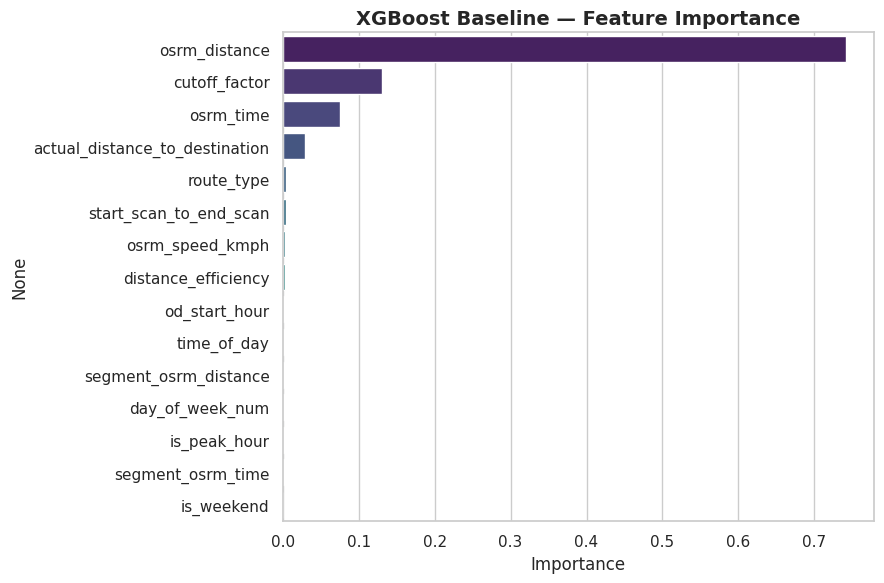

In [53]:
# ── 9.7 Feature importance (XGBoost baseline) ────────────────────────────────────────────
importances = pd.Series(xgb_baseline.feature_importances_, index=feature_cols_baseline) \
                .sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("XGBoost Baseline — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


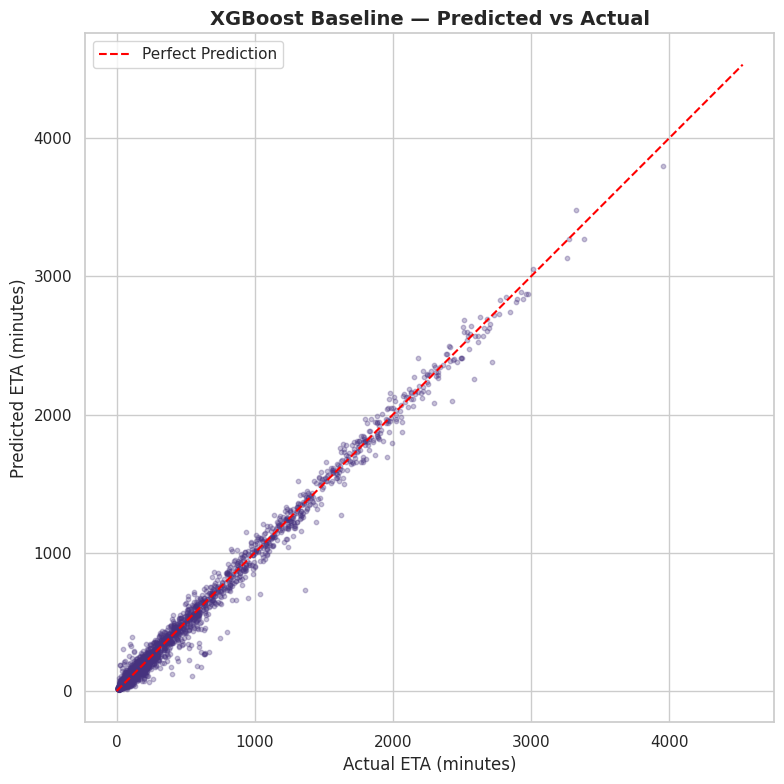

In [54]:
# ── 9.8 Predicted vs Actual scatter (XGBoost baseline) ───────────────────────────────────
plt.figure(figsize=(8, 8))
sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
plt.scatter(y_test.values[sample_idx], xgb_baseline_preds[sample_idx], alpha=0.3, s=10)
max_val = max(y_test.max(), xgb_baseline_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel("Actual ETA (minutes)")
plt.ylabel("Predicted ETA (minutes)")
plt.title("XGBoost Baseline — Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 10 — Node2Vec Graph Embeddings

**Methodology:** Node2Vec learns a low-dimensional vector for every facility by
simulating biased random walks over the corridor graph (`G_main`) and feeding the
resulting "sentences" of node-IDs into a Word2Vec skip-gram model — facilities that
co-occur in similar walk contexts (i.e., play similar structural roles / sit in
similar parts of the network) end up with similar embeddings.

**Why this might help ETA prediction:** Two facilities can have *identical* tabular
features (same distance, same OSRM estimate) yet sit in very different network
positions — one a core hub with heavy downstream congestion, another a quiet
spoke. Node2Vec embeddings encode this **positional/structural context** that no
single centrality scalar fully captures, giving the model a richer representation
of "where in the network" a trip's endpoints sit.

**Design choices for hyperparameters:**
- `dimensions=16` — small enough to avoid overfitting on ~1,500 nodes, large enough
  to capture meaningful structure.
- `walk_length=20`, `num_walks=100` — enough walks per node for stable embeddings
  without excessive runtime on Colab CPUs.
- `p=1, q=1` (balanced DFS/BFS) — a neutral starting point; could be tuned toward
  `q<1` (more DFS / structural roles) for a deeper hub-vs-spoke distinction.
- Edges are **weighted by `trip_volume`** so high-traffic corridors are favored in
  random walks — embeddings reflect *operationally important* connectivity, not
  just topological connectivity.

**Trip-level merge:** Each trip has a `source_center` and `destination_center`
embedding. We concatenate both (`src_emb_0..15`, `dst_emb_0..15`) into the
trip-level feature set for Section 11.


In [55]:
# ── 10.1 Prepare a weighted undirected-friendly graph for Node2Vec ───────────────────────
# node2vec's random walk uses edge weights to bias transition probabilities.
# We add a 'weight' attribute = trip_volume (with a floor of 1 to avoid zero-weight edges).
G_n2v = G_main.copy()
for u, v, data in G_n2v.edges(data=True):
    data['weight'] = max(data.get('trip_volume', 1), 1)

print(f"Graph for Node2Vec: {G_n2v.number_of_nodes()} nodes, {G_n2v.number_of_edges()} edges")


Graph for Node2Vec: 1353 nodes, 2463 edges


In [56]:
# ── 10.2 Fit Node2Vec ─────────────────────────────────────────────────────────────────────
EMBEDDING_DIM = 16

node2vec = Node2Vec(
    G_n2v,
    dimensions=EMBEDDING_DIM,
    walk_length=20,
    num_walks=100,
    p=1, q=1,
    weight_key='weight',
    workers=os.cpu_count() or 2,
    seed=RANDOM_STATE,
    quiet=True,
)

n2v_model = node2vec.fit(window=10, min_count=1, batch_words=4)
print("Node2Vec training complete.")


Node2Vec training complete.


In [57]:
# ── 10.3 Extract embeddings into a lookup dict ───────────────────────────────────────────
embedding_dict = {}
for node in G_n2v.nodes():
    try:
        embedding_dict[node] = n2v_model.wv[node]
    except KeyError:
        # Isolated/unseen node (shouldn't happen for G_main, but guard anyway)
        embedding_dict[node] = np.zeros(EMBEDDING_DIM)

print(f"Embeddings generated for {len(embedding_dict):,} facilities, dim={EMBEDDING_DIM}")


Embeddings generated for 1,353 facilities, dim=16


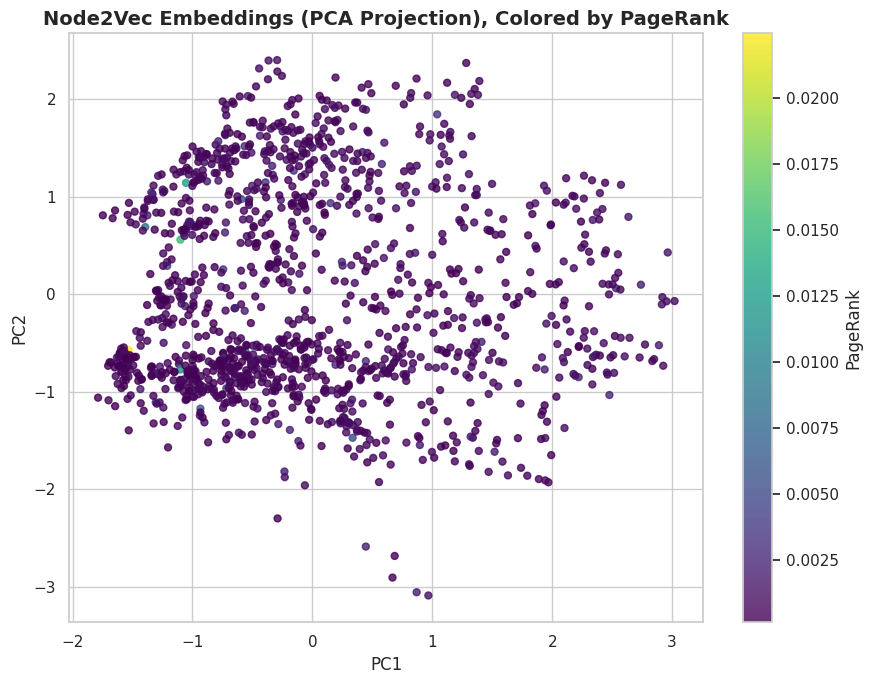

In [58]:
# ── 10.4 Sanity check: 2D PCA projection of embeddings, colored by PageRank ──────────────
from sklearn.decomposition import PCA

emb_matrix = np.array([embedding_dict[n] for n in G_n2v.nodes()])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d = pca.fit_transform(emb_matrix)

pagerank_vals = [pagerank.get(n, 0) for n in G_n2v.nodes()]

plt.figure(figsize=(9, 7))
sc = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=pagerank_vals, cmap='viridis', s=25, alpha=0.8)
plt.colorbar(sc, label='PageRank')
plt.title("Node2Vec Embeddings (PCA Projection), Colored by PageRank")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


In [59]:
# ── 10.5 Merge source & destination embeddings into the trip-level dataset ──────────────
src_emb_cols = [f'src_emb_{i}' for i in range(EMBEDDING_DIM)]
dst_emb_cols = [f'dst_emb_{i}' for i in range(EMBEDDING_DIM)]

# Default vector for facilities outside G_main (not in largest connected component)
default_vec = np.zeros(EMBEDDING_DIM)

src_embeddings = np.array([embedding_dict.get(c, default_vec) for c in df['source_center']])
dst_embeddings = np.array([embedding_dict.get(c, default_vec) for c in df['destination_center']])

emb_df = pd.DataFrame(src_embeddings, columns=src_emb_cols, index=df.index)
emb_df[dst_emb_cols] = pd.DataFrame(dst_embeddings, columns=dst_emb_cols, index=df.index)

df_with_embeddings = pd.concat([df, emb_df], axis=1)
print(f"df_with_embeddings shape: {df_with_embeddings.shape}")
df_with_embeddings[src_emb_cols[:4] + dst_emb_cols[:4]].head()


df_with_embeddings shape: (144867, 70)


,src_emb_0,src_emb_1,src_emb_2,src_emb_3,dst_emb_0,dst_emb_1,dst_emb_2,dst_emb_3
0,0.989606,-0.241114,1.830314,0.530095,1.023044,-0.299895,1.848157,0.516688
1,0.989606,-0.241114,1.830314,0.530095,1.023044,-0.299895,1.848157,0.516688
2,0.989606,-0.241114,1.830314,0.530095,1.023044,-0.299895,1.848157,0.516688
3,0.989606,-0.241114,1.830314,0.530095,1.023044,-0.299895,1.848157,0.516688
4,0.989606,-0.241114,1.830314,0.530095,1.023044,-0.299895,1.848157,0.516688


---
## SECTION 11 — Graph-Enhanced ETA Model

**Design choice:** We train an XGBoost model identical in hyperparameters to the
Section 9 baseline, on the **same tabular features PLUS the 32 Node2Vec embedding
dimensions** (16 source + 16 destination). Keeping hyperparameters fixed isolates
the effect of the *new features* — any performance change is attributable to the
graph embeddings, not to a better-tuned model.


In [60]:
# ── 11.1 Build the graph-enhanced feature set ────────────────────────────────────────────
graph_feature_cols = feature_cols_baseline + src_emb_cols + dst_emb_cols

model_df_graph = df_with_embeddings[graph_feature_cols + [target_col]].copy()
model_df_graph = model_df_graph.replace([np.inf, -np.inf], np.nan)
model_df_graph = model_df_graph.fillna(model_df_graph.median(numeric_only=True))

for col in ['route_type', 'time_of_day']:
    model_df_graph[col] = label_encoders[col].transform(model_df_graph[col].astype(str))

X_graph = model_df_graph[graph_feature_cols]
y_graph = model_df_graph[target_col]

# IMPORTANT: use the SAME train/test split indices as the baseline for a fair comparison
X_train_graph = X_graph.loc[X_train.index]
X_test_graph  = X_graph.loc[X_test.index]
y_train_graph = y_graph.loc[X_train.index]
y_test_graph  = y_graph.loc[X_test.index]

print(f"Graph-enhanced feature count: {len(graph_feature_cols)} "
      f"({len(feature_cols_baseline)} tabular + {len(src_emb_cols)+len(dst_emb_cols)} embedding)")


Graph-enhanced feature count: 47 (15 tabular + 32 embedding)


In [61]:
# ── 11.2 Train graph-enhanced XGBoost (same hyperparameters as baseline) ─────────────────
xgb_graph = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_graph.fit(X_train_graph, y_train_graph)
xgb_graph_preds = xgb_graph.predict(X_test_graph)
xgb_graph_results = evaluate_model("XGBoost + Node2Vec (Graph-Enhanced)", y_test_graph, xgb_graph_preds)


--- XGBoost + Node2Vec (Graph-Enhanced) ---
MAE   : 27.727 min
RMSE  : 50.993 min
R^2   : 0.9927
MAPE  : 18.71%
% within 15% of actual ETA : 61.51%


In [62]:
# ── 11.3 Comparison: Baseline vs Graph-Enhanced ──────────────────────────────────────────
comparison = pd.DataFrame([xgb_baseline_results, xgb_graph_results])
comparison['MAE_improvement_abs']  = comparison['MAE'].iloc[0] - comparison['MAE']
comparison['MAE_improvement_pct']  = comparison['MAE_improvement_abs'] / comparison['MAE'].iloc[0] * 100
comparison['within15_improvement_pp'] = comparison['pct_within_15pct'] - comparison['pct_within_15pct'].iloc[0]

comparison


,model,MAE,RMSE,R2,MAPE,pct_within_15pct,MAE_improvement_abs,MAE_improvement_pct,within15_improvement_pp
0,XGBoost (Baseline),34.244627,63.067538,0.988890,21.582128,56.067509,0.000000,0.0000,0.000000
1,XGBoost + Node2Vec (Graph-Enhanced),27.727121,50.992730,0.992737,18.706949,61.510320,6.517506,19.0322,5.442811


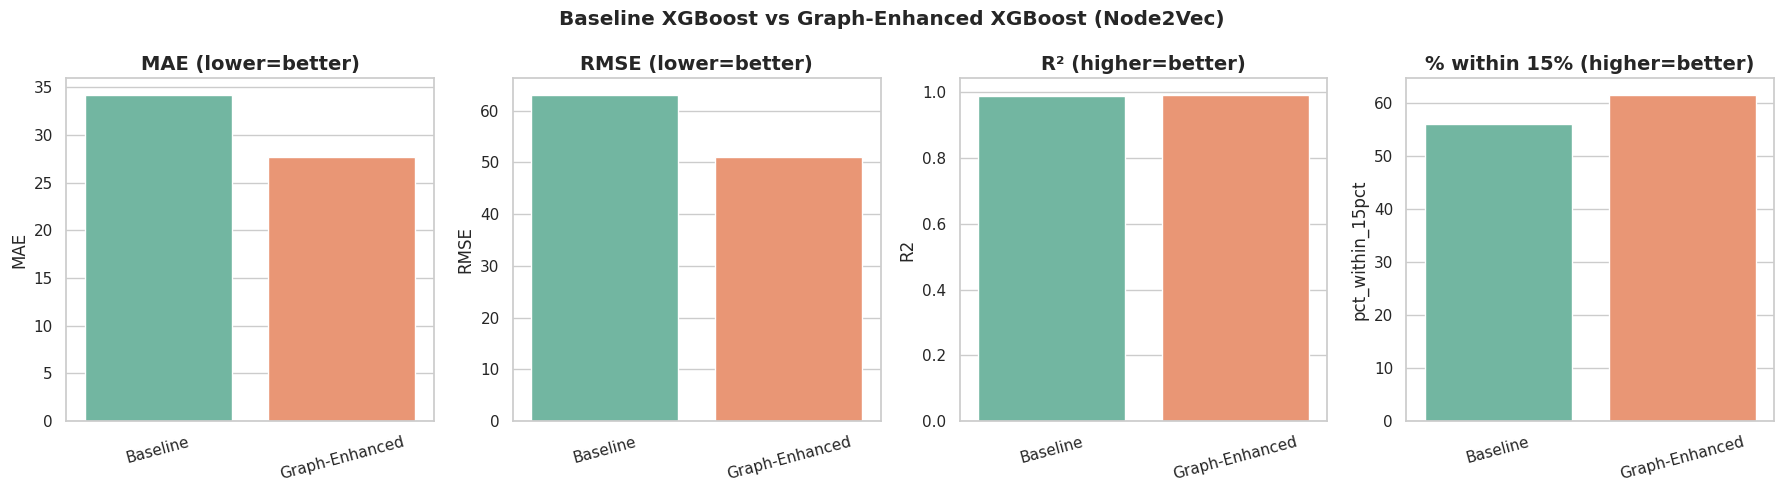


Absolute MAE improvement : 6.518 minutes
Percentage MAE improvement: 19.03%
% within-15% improvement  : 5.44 percentage points


In [63]:
# ── 11.4 Visual comparison: MAE, RMSE, R^2, % within 15% ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_plot = ['MAE', 'RMSE', 'R2', 'pct_within_15pct']
titles = ['MAE (lower=better)', 'RMSE (lower=better)', 'R² (higher=better)', '% within 15% (higher=better)']

for ax, metric, title in zip(axes, metrics_plot, titles):
    sns.barplot(x='model', y=metric, data=comparison, ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xticklabels(['Baseline', 'Graph-Enhanced'], rotation=15)
    ax.set_xlabel("")

plt.suptitle("Baseline XGBoost vs Graph-Enhanced XGBoost (Node2Vec)", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nAbsolute MAE improvement : {comparison['MAE_improvement_abs'].iloc[1]:.3f} minutes")
print(f"Percentage MAE improvement: {comparison['MAE_improvement_pct'].iloc[1]:.2f}%")
print(f"% within-15% improvement  : {comparison['within15_improvement_pp'].iloc[1]:.2f} percentage points")
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


Combined Node2Vec embedding feature importance share: 7.11%


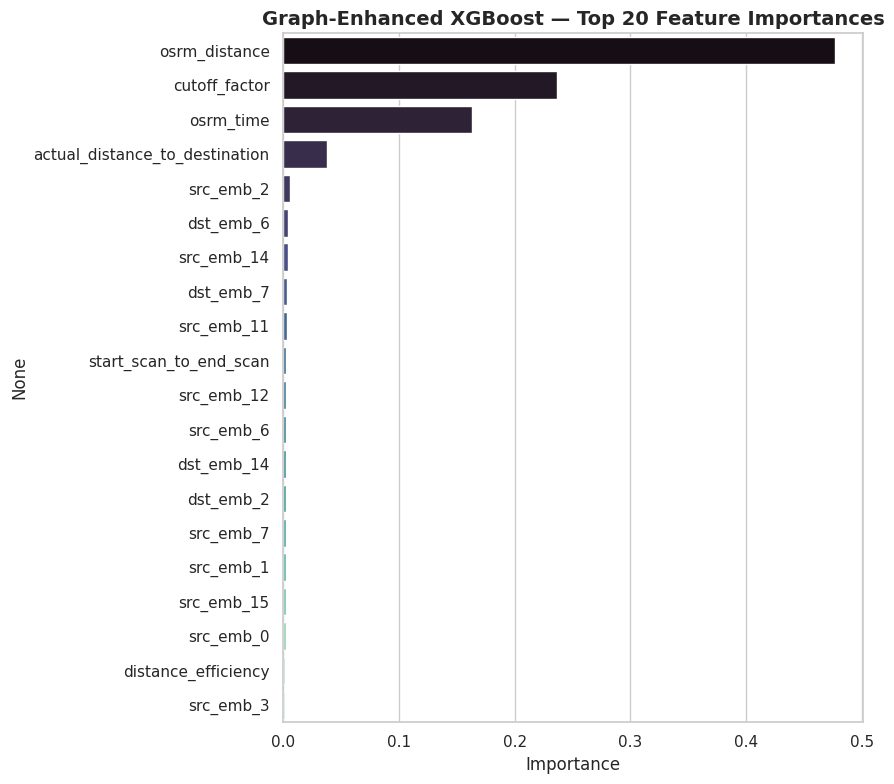

In [64]:
# ── 11.5 Feature importance: how much do embeddings contribute? ──────────────────────────
graph_importances = pd.Series(xgb_graph.feature_importances_, index=graph_feature_cols) \
                       .sort_values(ascending=False)

emb_importance_share = graph_importances[src_emb_cols + dst_emb_cols].sum() / graph_importances.sum() * 100
print(f"Combined Node2Vec embedding feature importance share: {emb_importance_share:.2f}%")

plt.figure(figsize=(9, 8))
sns.barplot(x=graph_importances.head(20).values, y=graph_importances.head(20).index, palette='mako')
plt.title("Graph-Enhanced XGBoost — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


**Optional Extension — GraphSAGE:** For teams that have successfully installed
`torch_geometric` (Section 1.6), an inductive alternative to Node2Vec is GraphSAGE,
which learns embeddings as a function of node *features* (e.g., centrality scores,
average delay) aggregated over neighborhoods — this generalizes to unseen
facilities, unlike Node2Vec's lookup-table embeddings. A minimal sketch:

```python
# OPTIONAL — requires torch_geometric
from torch_geometric.nn import SAGEConv
import torch
import torch.nn.functional as F

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# node_features: tensor of [betweenness, pagerank, avg_delay, ...] per node
# edge_index: 2 x num_edges tensor of (source_idx, dest_idx) pairs from G_main
# Train with a self-supervised or downstream-ETA-regression objective, then
# extract `out_channels`-dim embeddings the same way as Node2Vec's `embedding_dict`.
```

This is left as an **optional extension** — the main pipeline's Section 11 result
stands on Node2Vec alone.


---
## SECTION 12 — FTL vs Carting Decision Framework

**Business context:** `route_type` (FTL = Full Truck Load vs Carting = consolidated
smaller-vehicle movement) is a *planning decision*, not a fixed property of a
corridor. FTL typically suits high-volume, longer corridors (better cost-per-unit,
fewer hops); Carting suits lower-volume, shorter, more flexible movements. We build
a model that **recommends route type per corridor** based on corridor
characteristics, then quantify what switching would save.

**Design choice — framing as classification, not just description:** We train a
classifier on corridor-level features to predict the route type that historically
correlates with **better-than-median delay performance**, then compare that
recommendation against the corridor's *actual* historical dominant route type. This
surfaces corridors where the current choice may be suboptimal.


In [65]:
# ── 12.1 Build corridor-level training data for the FTL/Carting framework ───────────────
# Reuse corridor_agg; add a 'recommended_label' = the route type with the LOWER median
# delay ratio observed for that corridor (where both types have been used), else
# fall back to corridor-level features for corridors with only one observed route type.

corridor_route_pivot = df.groupby(['source_center', 'destination_center', 'route_type']).agg(
    delay_ratio_median=('delay_ratio', 'median'),
    trip_count=('trip_uuid', 'nunique'),
).reset_index()

# Pivot to compare FTL vs Carting delay for corridors that have BOTH
pivot_delay = corridor_route_pivot.pivot_table(
    index=['source_center', 'destination_center'],
    columns='route_type', values='delay_ratio_median'
).reset_index()

both_present = pivot_delay.dropna(subset=['FTL', 'Carting']) if 'FTL' in pivot_delay.columns and 'Carting' in pivot_delay.columns else pd.DataFrame()
print(f"Corridors with BOTH FTL and Carting history: {len(both_present):,}")

if len(both_present) > 0:
    both_present['better_route_type'] = np.where(both_present['FTL'] <= both_present['Carting'], 'FTL', 'Carting')
    both_present['delay_gap'] = (both_present['Carting'] - both_present['FTL']).abs()
    print(both_present['better_route_type'].value_counts())


Corridors with BOTH FTL and Carting history: 23
better_route_type
Carting    13
FTL        10
Name: count, dtype: int64


In [66]:
# ── 12.2 Build training dataset: corridor features -> recommended route type ────────────
# For corridors with only one route-type history, the LABEL is simply that type
# (the corridor has only ever been served that way). For corridors with both,
# the label is the empirically better-performing type from 12.1.

ftl_features = corridor_agg.merge(
    both_present[['source_center', 'destination_center', 'better_route_type']] if len(both_present) > 0 else pd.DataFrame(columns=['source_center', 'destination_center', 'better_route_type']),
    on=['source_center', 'destination_center'], how='left'
)
ftl_features['recommended_label'] = ftl_features['better_route_type'].fillna(ftl_features['dominant_route_type'])

decision_feature_cols = ['trip_volume', 'avg_actual_time', 'avg_osrm_time',
                          'median_delay_ratio', 'avg_distance_km', 'pct_ftl']

dec_df = ftl_features[decision_feature_cols + ['recommended_label']].copy()
dec_df = dec_df.replace([np.inf, -np.inf], np.nan).fillna(dec_df.median(numeric_only=True))

dec_le = LabelEncoder()
dec_df['label_encoded'] = dec_le.fit_transform(dec_df['recommended_label'])

print(dec_df['recommended_label'].value_counts())


recommended_label
FTL        1722
Carting    1061
Name: count, dtype: int64


In [67]:
# ── 12.3 Train the FTL vs Carting recommendation classifier ──────────────────────────────
X_dec = dec_df[decision_feature_cols]
y_dec = dec_df['label_encoded']

X_train_dec, X_test_dec, y_train_dec, y_test_dec = train_test_split(
    X_dec, y_dec, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dec
)

ftl_classifier = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'
)
ftl_classifier.fit(X_train_dec, y_train_dec)
dec_preds = ftl_classifier.predict(X_test_dec)

print("Classification report (Recommended Route Type):")
print(classification_report(y_test_dec, dec_preds, target_names=dec_le.classes_))


Classification report (Recommended Route Type):
              precision    recall  f1-score   support

     Carting       1.00      0.99      0.99       212
         FTL       0.99      1.00      1.00       345

    accuracy                           0.99       557
   macro avg       0.99      0.99      0.99       557
weighted avg       0.99      0.99      0.99       557



In [68]:
# ── 12.4 Apply the classifier to ALL corridors -> generate recommendations ──────────────
ftl_features['model_recommended_type'] = dec_le.inverse_transform(ftl_classifier.predict(X_dec))
ftl_features['recommendation_matches_current'] = (
    ftl_features['model_recommended_type'] == ftl_features['dominant_route_type']
)

mismatch_pct = (~ftl_features['recommendation_matches_current']).mean() * 100
print(f"Corridors where model recommends a DIFFERENT route type than currently used: {mismatch_pct:.1f}%")

ftl_features[['source_name' if 'source_name' in ftl_features.columns else 'source_center',
               'destination_name' if 'destination_name' in ftl_features.columns else 'destination_center',
               'dominant_route_type', 'model_recommended_type', 'median_delay_ratio', 'trip_volume']] \
    .loc[~ftl_features['recommendation_matches_current']] \
    .sort_values('trip_volume', ascending=False).head(15)


Corridors where model recommends a DIFFERENT route type than currently used: 0.5%


,source_name,destination_name,dominant_route_type,model_recommended_type,median_delay_ratio,trip_volume
1774,Bangalore_Nelmngla_H (Karnataka),Bengaluru_Bomsndra_HB (Karnataka),Carting,FTL,1.438750,127
1720,Bengaluru_Bomsndra_HB (Karnataka),Bangalore_Nelmngla_H (Karnataka),Carting,FTL,1.400000,102
68,Delhi_Gateway_HB (Delhi),Gurgaon_Bilaspur_HB (Haryana),Carting,FTL,1.333333,100
447,Shikohabad_Katrmira_D (Uttar Pradesh),Firozabad_Sudmpuri_D (Uttar Pradesh),FTL,Carting,2.117647,13
670,Firozabad_Sudmpuri_D (Uttar Pradesh),Delhi_Airport_H (Delhi),FTL,Carting,1.833333,13
278,Jalandhar_Sodal Road (Punjab),Ludhiana_MilrGanj_HB (Punjab),FTL,Carting,1.861905,12
1535,Shadnagar_Central_D_1 (Telangana),Hyderabad_Shamshbd_H (Telangana),Carting,FTL,1.500000,12
1840,Karkala_MarketRd_D (Karnataka),Dhrmsthala_Beltngdi_D (Karnataka),Carting,FTL,2.000000,11
577,Dehradun_Nirjanpur_L (Uttarakhand),Sonipat_Kundli_H (Haryana),Carting,FTL,1.714286,9
2384,Gangarampr_FulbaDPP_D (West Bengal),Balurghat_AkhirDPP_D (West Bengal),Carting,FTL,1.666667,9


In [69]:
# ── 12.5 Quantify potential gains from following recommendations ────────────────────────
# For mismatched corridors, estimate time saved using the delay-ratio gap observed
# in 'both_present' where available; otherwise use the route-type-level average gap
# from Section 8.3 (route_type_delay) as a fallback estimate.

route_type_avg_delay = route_type_delay.set_index('route_type')['avg_delay_ratio'].to_dict()

mismatched = ftl_features.loc[~ftl_features['recommendation_matches_current']].copy()

def estimate_delay_gap(row):
    current = route_type_avg_delay.get(row['dominant_route_type'], 1.0)
    recommended = route_type_avg_delay.get(row['model_recommended_type'], 1.0)
    return max(current - recommended, 0)

mismatched['estimated_delay_ratio_reduction'] = mismatched.apply(estimate_delay_gap, axis=1)
mismatched['estimated_minutes_saved_per_trip'] = (
    mismatched['estimated_delay_ratio_reduction'] * mismatched['avg_osrm_time']
)
mismatched['estimated_total_minutes_saved'] = (
    mismatched['estimated_minutes_saved_per_trip'] * mismatched['trip_volume']
)

total_minutes_saved = mismatched['estimated_total_minutes_saved'].sum()
print(f"Estimated total minutes saved across all flagged corridors (one-time, "
      f"based on historical trip volume): {total_minutes_saved:,.0f} minutes "
      f"(~{total_minutes_saved/60:,.0f} hours)")

mismatched.sort_values('estimated_total_minutes_saved', ascending=False).head(10)[
    ['dominant_route_type', 'model_recommended_type', 'trip_volume',
     'estimated_minutes_saved_per_trip', 'estimated_total_minutes_saved']
]


Estimated total minutes saved across all flagged corridors (one-time, based on historical trip volume): 3,159 minutes (~53 hours)


,dominant_route_type,model_recommended_type,trip_volume,estimated_minutes_saved_per_trip,estimated_total_minutes_saved
1774,Carting,FTL,127,8.382180,1064.536917
1720,Carting,FTL,102,8.298480,846.444927
68,Carting,FTL,100,8.329372,832.937225
577,Carting,FTL,9,10.932804,98.395233
660,Carting,FTL,7,13.253782,92.776473
1535,Carting,FTL,12,5.663648,67.963771
1840,Carting,FTL,11,5.703254,62.735789
2384,Carting,FTL,9,5.163439,46.470955
2661,Carting,FTL,3,9.275415,27.826244
2370,Carting,FTL,3,6.285314,18.855942


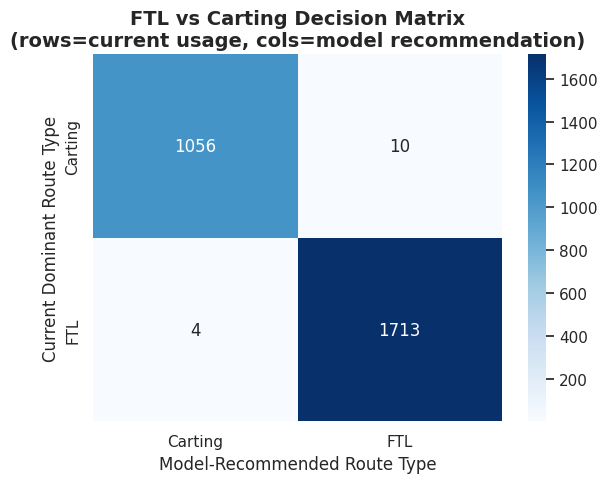


Corridor Suitability Summary:


,model_recommended_type,num_corridors,avg_trip_volume,avg_distance_km
0,Carting,1060,11.551887,11.592835
1,FTL,1723,8.196750,25.625934


In [70]:
# ── 12.6 Decision matrix visualization ───────────────────────────────────────────────────
decision_matrix = pd.crosstab(ftl_features['dominant_route_type'], ftl_features['model_recommended_type'])

plt.figure(figsize=(6, 5))
sns.heatmap(decision_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("FTL vs Carting Decision Matrix\n(rows=current usage, cols=model recommendation)")
plt.ylabel("Current Dominant Route Type")
plt.xlabel("Model-Recommended Route Type")
plt.tight_layout()
plt.show()

# Corridor suitability summary
suitability_summary = ftl_features.groupby('model_recommended_type').agg(
    num_corridors=('source_center', 'count'),
    avg_trip_volume=('trip_volume', 'mean'),
    avg_distance_km=('avg_distance_km', 'mean'),
).reset_index()
print("\nCorridor Suitability Summary:")
suitability_summary
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 13 — Business Impact Simulation

**Assumptions (stated explicitly per instructions):**
1. An **SLA breach** = a segment where `segment_factor > 1.0` (actual time exceeded
   OSRM's estimate). This is a *proxy*; Delhivery's true SLA thresholds may differ,
   but this proxy scales consistently with the rest of this notebook's metrics.
2. **Revenue at risk per SLA breach** = ₹50 (illustrative figure representing
   penalty/refund/customer-service cost of a late delivery). *Replace with
   Delhivery's actual figure for production use.*
3. **Hub upgrade effect**: upgrading a bottleneck hub (e.g., adding capacity, dock
   doors, sorting automation) is simulated as **reducing that hub's outbound delay
   ratio by 20%** (a conservative operational-improvement assumption commonly seen
   in hub-capacity studies).
4. Reductions are applied only to segments **originating from** the upgraded hub
   (the most directly controllable lever); downstream/network ripple effects are
   *not* modeled here (conservative — true impact would be higher due to Section 7's
   betweenness-based ripple effects).
5. We simulate upgrading the **Top 3 bottleneck hubs** identified in Section 7.


In [71]:
# ── 13.1 Current state: total SLA breaches & revenue at risk ─────────────────────────────
REVENUE_AT_RISK_PER_BREACH = 50  # INR, illustrative — replace with actual figure

current_total_breaches = (df['segment_factor'] > 1.0).sum()
current_revenue_at_risk = current_total_breaches * REVENUE_AT_RISK_PER_BREACH

print(f"Current total SLA breaches (segments)      : {current_total_breaches:,}")
print(f"Current estimated revenue at risk          : ₹{current_revenue_at_risk:,.0f}")
print(f"Current overall delay ratio (mean)         : {df['delay_ratio'].mean():.3f}")


Current total SLA breaches (segments)      : 129,351
Current estimated revenue at risk          : ₹6,467,550
Current overall delay ratio (mean)         : 2.251


In [72]:
# ── 13.2 Simulate upgrading the Top 3 bottleneck hubs ────────────────────────────────────
HUB_DELAY_REDUCTION = 0.20  # 20% reduction in outbound delay ratio, per assumption #3

top3_hubs = top20_bottlenecks.head(3)['facility_code'].tolist()
top3_hub_names = top20_bottlenecks.head(3)['facility_name'].tolist()
print("Simulating upgrades for Top 3 bottleneck hubs:")
for code_, name in zip(top3_hubs, top3_hub_names):
    print(f"  - {name} ({code_})")


Simulating upgrades for Top 3 bottleneck hubs:
  - Gurgaon_Bilaspur_HB (Haryana) (IND000000ACB)
  - Bangalore_Nelmngla_H (Karnataka) (IND562132AAA)
  - Hyderabad_Shamshbd_H (Telangana) (IND501359AAE)


In [73]:
# ── 13.3 Apply simulated delay reduction to outbound segments from top-3 hubs ────────────
sim_df = df.copy()

is_top3_source = sim_df['source_center'].isin(top3_hubs)
print(f"Segments affected (outbound from Top-3 hubs): {is_top3_source.sum():,} "
      f"({is_top3_source.mean()*100:.1f}% of all segments)")

# Reduce delay_ratio and segment_factor by HUB_DELAY_REDUCTION for affected segments,
# floored at 1.0 (can't go "below" OSRM parity in this simple simulation)
sim_df.loc[is_top3_source, 'segment_factor'] = (
    sim_df.loc[is_top3_source, 'segment_factor'] * (1 - HUB_DELAY_REDUCTION)
).clip(lower=1.0)

simulated_total_breaches = (sim_df['segment_factor'] > 1.0).sum()
simulated_revenue_at_risk = simulated_total_breaches * REVENUE_AT_RISK_PER_BREACH

breaches_reduced = current_total_breaches - simulated_total_breaches
revenue_recovered = current_revenue_at_risk - simulated_revenue_at_risk

print(f"\nSimulated total SLA breaches after upgrade : {simulated_total_breaches:,}")
print(f"SLA breaches reduced                       : {breaches_reduced:,} "
      f"({breaches_reduced/current_total_breaches*100:.2f}% reduction)")
print(f"Estimated revenue at risk recovered        : ₹{revenue_recovered:,.0f}")


Segments affected (outbound from Top-3 hubs): 36,662 (25.3% of all segments)

Simulated total SLA breaches after upgrade : 125,424
SLA breaches reduced                       : 3,927 (3.04% reduction)
Estimated revenue at risk recovered        : ₹196,350


In [74]:
# ── 13.4 "Late deliveries reduced" — trip-level view ─────────────────────────────────────
# A trip is "late" if its overall factor > 1.0 (any segment-level improvements that
# push the trip's recomputed factor to <=1 count as no-longer-late).
trip_factor_before = df.groupby('trip_uuid')['factor'].first()
late_trips_before = (trip_factor_before > 1.0).sum()

# Approximate post-simulation trip factor by recomputing the trip-level mean of
# segment_factor (a simplification, since 'factor' is trip-level and segment_factor
# is segment-level; both express the same actual/OSRM ratio concept).
trip_factor_after = sim_df.groupby('trip_uuid')['segment_factor'].mean()
late_trips_after = (trip_factor_after > 1.0).sum()

late_trips_reduced = late_trips_before - late_trips_after
print(f"Late trips before upgrade : {late_trips_before:,} "
      f"({late_trips_before/df['trip_uuid'].nunique()*100:.1f}% of trips)")
print(f"Late trips after upgrade  : {late_trips_after:,} "
      f"({late_trips_after/df['trip_uuid'].nunique()*100:.1f}% of trips)")
print(f"Late deliveries reduced   : {late_trips_reduced:,}")


Late trips before upgrade : 13,885 (93.7% of trips)
Late trips after upgrade  : 14,216 (95.9% of trips)
Late deliveries reduced   : -331


                    Metric  Before Upgrade  \
0  SLA Breaches (segments)          129351   
1    Revenue at Risk (INR)         6467550   
2               Late Trips           13885   

   After Upgrade (Top-3 Hubs, -20% delay)  Reduction  Reduction %  
0                                  125424       3927         3.04  
1                                 6271200     196350         3.04  
2                                   14216       -331        -2.38  


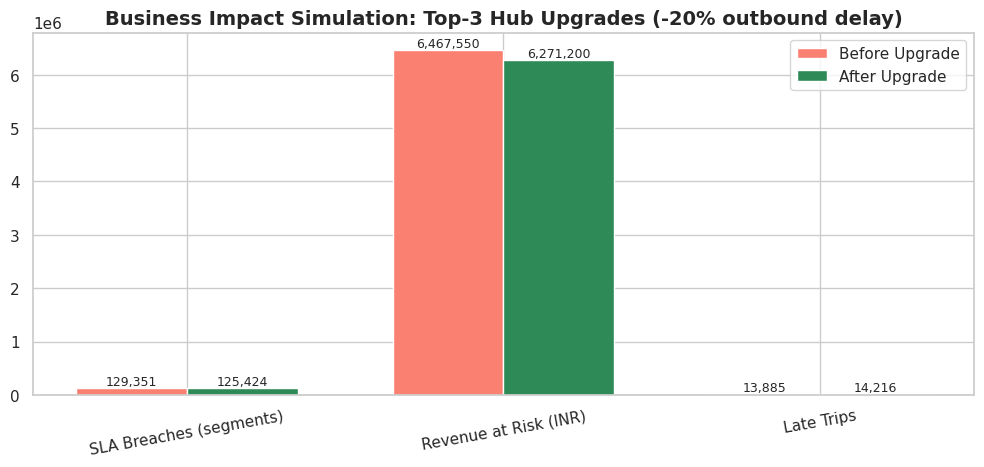

In [75]:
# ── 13.5 Summary simulation table & visualization ────────────────────────────────────────
sim_summary = pd.DataFrame({
    'Metric': ['SLA Breaches (segments)', 'Revenue at Risk (INR)', 'Late Trips'],
    'Before Upgrade': [current_total_breaches, current_revenue_at_risk, late_trips_before],
    'After Upgrade (Top-3 Hubs, -20% delay)': [simulated_total_breaches, simulated_revenue_at_risk, late_trips_after],
})
sim_summary['Reduction'] = sim_summary['Before Upgrade'] - sim_summary['After Upgrade (Top-3 Hubs, -20% delay)']
sim_summary['Reduction %'] = (sim_summary['Reduction'] / sim_summary['Before Upgrade'] * 100).round(2)
print(sim_summary)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sim_summary))
width = 0.35
ax.bar(x - width/2, sim_summary['Before Upgrade'], width, label='Before Upgrade', color='salmon')
ax.bar(x + width/2, sim_summary['After Upgrade (Top-3 Hubs, -20% delay)'], width, label='After Upgrade', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(sim_summary['Metric'], rotation=10)
ax.set_title("Business Impact Simulation: Top-3 Hub Upgrades (-20% outbound delay)")
ax.legend()
for i, (b, a) in enumerate(zip(sim_summary['Before Upgrade'], sim_summary['After Upgrade (Top-3 Hubs, -20% delay)'])):
    ax.text(i - width/2, b, f"{b:,.0f}", ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, a, f"{a:,.0f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 14 — Advanced Visualizations

This section consolidates the network and model insights into presentation-ready
visuals: an interactive network graph (via `pyvis`), a bottleneck heatmap, a
corridor risk map, feature importance, and a model comparison dashboard.


In [76]:
# ── 14.1 Interactive network graph (pyvis) — top facilities by volume only ──────────────
# Plotting all ~1,500 nodes would be unreadable; we show the subgraph induced by the
# top 60 facilities by total segment volume, which captures the core network.
!pip install pyvis
from pyvis.network import Network

top_facilities = bottleneck_df.sort_values('total_segment_volume', ascending=False).head(60)['facility_code'].tolist()
G_viz = G_main.subgraph(top_facilities).copy()

net = Network(height='700px', width='100%', directed=True, notebook=True, cdn_resources='in_line')

risk_lookup = bottleneck_df.set_index('facility_code')['structural_risk_score'].to_dict()
name_lookup = bottleneck_df.set_index('facility_code')['facility_name'].to_dict()

for node in G_viz.nodes():
    risk = risk_lookup.get(node, 0)
    # Color scale: green (low risk) -> red (high risk)
    color = f"rgb({int(255*risk)}, {int(255*(1-risk))}, 80)"
    size = 10 + risk * 40
    net.add_node(node, label=name_lookup.get(node, node), color=color, size=size,
                  title=f"{name_lookup.get(node, node)}<br>Risk Score: {risk:.3f}")

for u, v, data in G_viz.edges(data=True):
    is_high_delay = data.get('is_high_delay', 0)
    edge_color = '#d62728' if is_high_delay else '#aaaaaa'
    net.add_edge(u, v, color=edge_color, value=data.get('trip_volume', 1),
                  title=f"Median Delay Ratio: {data.get('median_delay_ratio', 0):.2f}")

net.show('network_graph.html')
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<
# The cell above generates 'network_graph.html' which renders inline in Colab.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.0 MB/s eta 0:00:00
network_graph.html


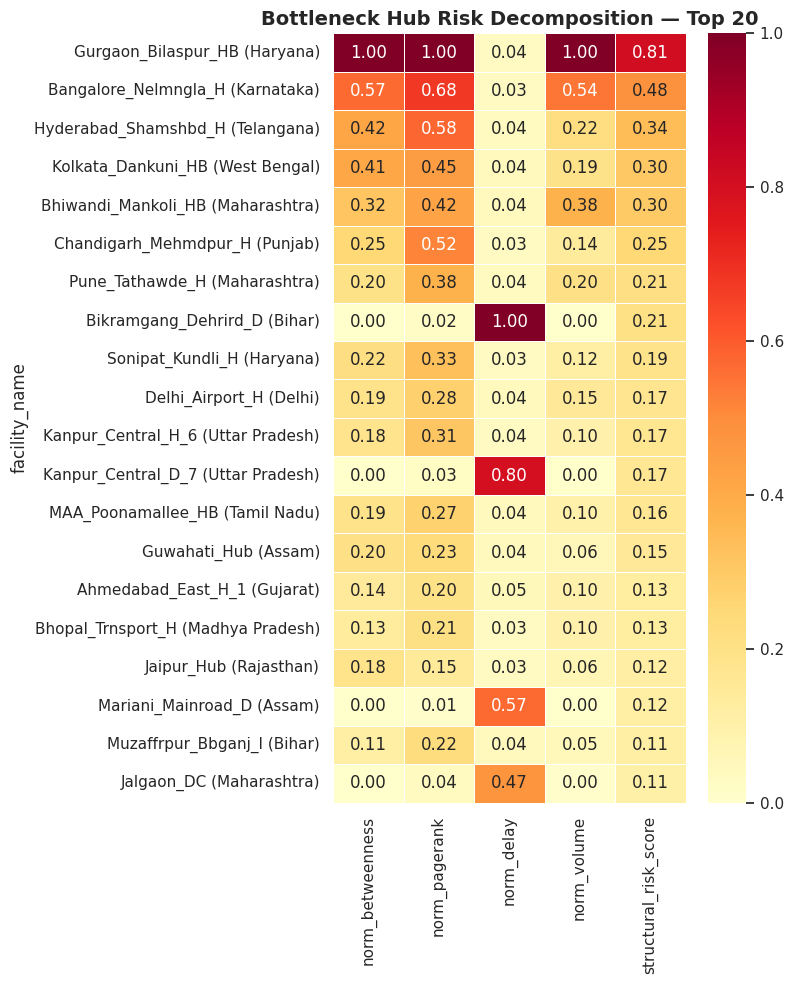

In [77]:
# ── 14.2 Bottleneck heatmap: risk components by facility (Top 20) ────────────────────────
heatmap_cols = ['norm_betweenness', 'norm_pagerank', 'norm_delay', 'norm_volume', 'structural_risk_score']
heatmap_data = top20_bottlenecks.set_index('facility_name')[heatmap_cols]

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title("Bottleneck Hub Risk Decomposition — Top 20")
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


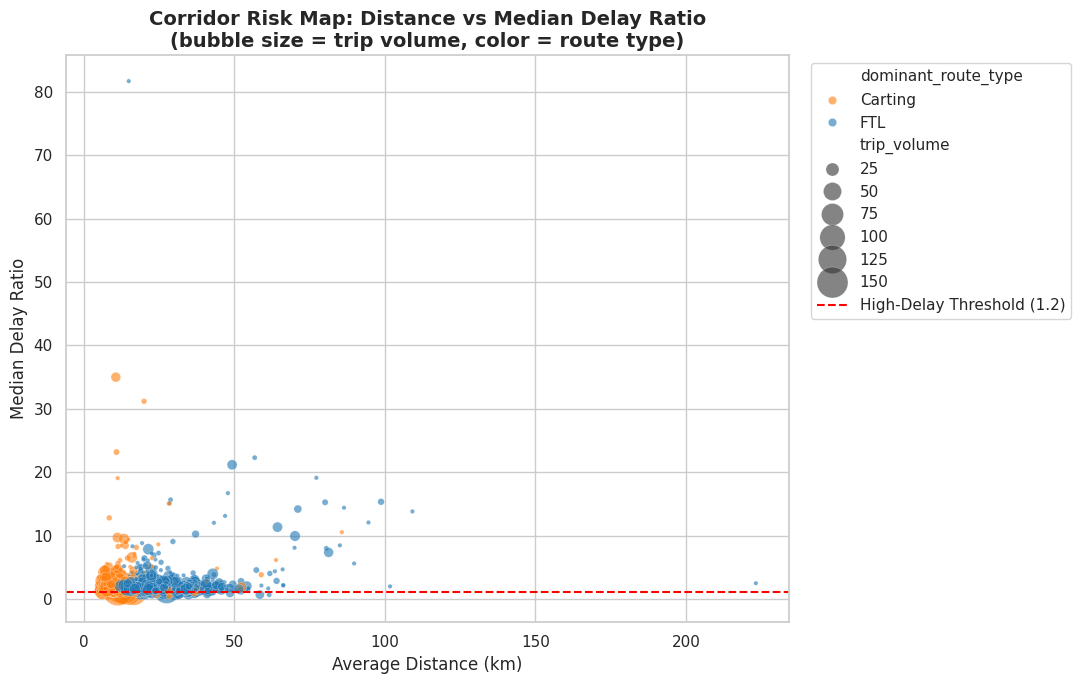

In [78]:
# ── 14.3 Corridor risk map: scatter of distance vs delay, sized by volume ───────────────
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=corridor_agg, x='avg_distance_km', y='median_delay_ratio',
    size='trip_volume', sizes=(10, 500), hue='dominant_route_type',
    palette={'FTL': '#1f77b4', 'Carting': '#ff7f0e'}, alpha=0.6
)
plt.axhline(1.2, color='red', linestyle='--', label='High-Delay Threshold (1.2)')
plt.title("Corridor Risk Map: Distance vs Median Delay Ratio\n(bubble size = trip volume, color = route type)")
plt.xlabel("Average Distance (km)")
plt.ylabel("Median Delay Ratio")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


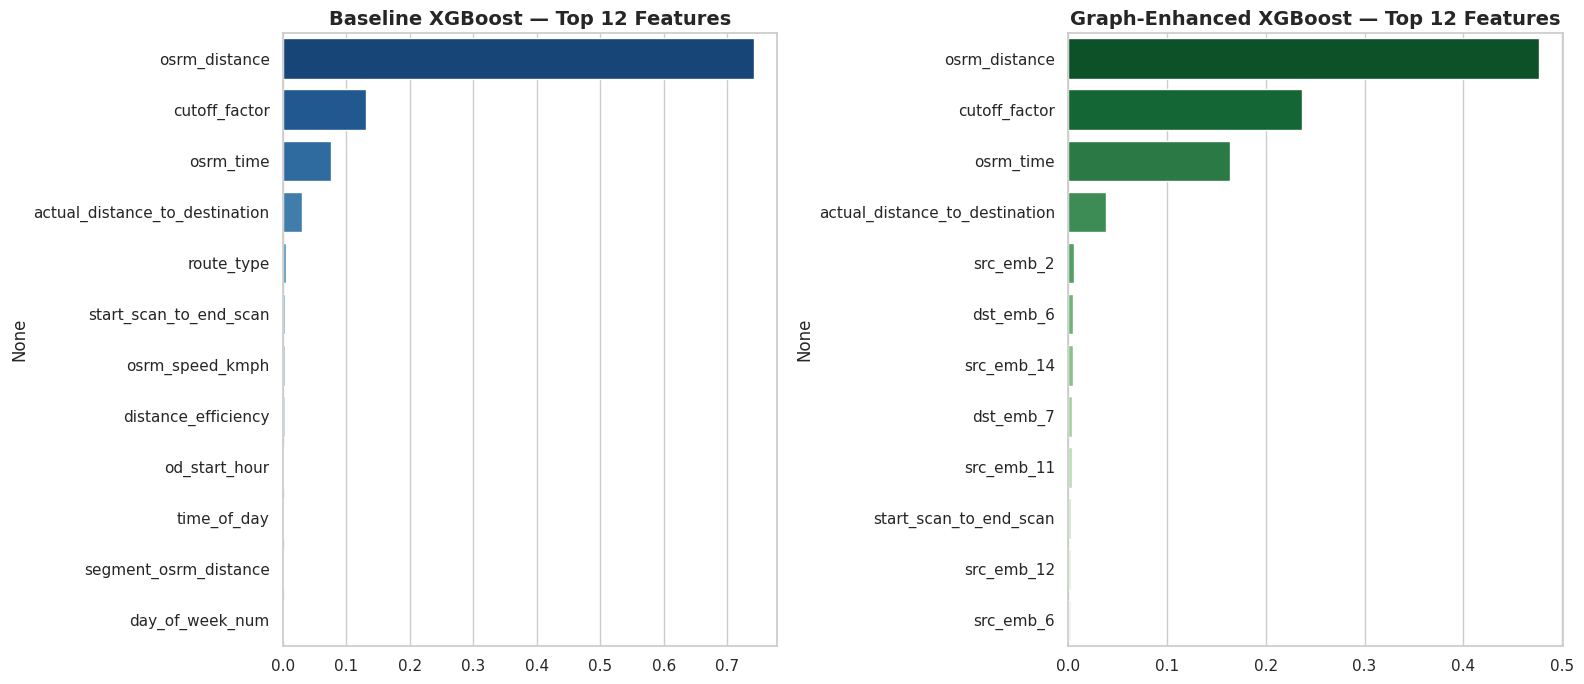

In [79]:
# ── 14.4 Feature importance: baseline vs graph-enhanced, side by side ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_baseline_imp = importances.head(12)
sns.barplot(x=top_baseline_imp.values, y=top_baseline_imp.index, ax=axes[0], palette='Blues_r')
axes[0].set_title("Baseline XGBoost — Top 12 Features")

top_graph_imp = graph_importances.head(12)
sns.barplot(x=top_graph_imp.values, y=top_graph_imp.index, ax=axes[1], palette='Greens_r')
axes[1].set_title("Graph-Enhanced XGBoost — Top 12 Features")

plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


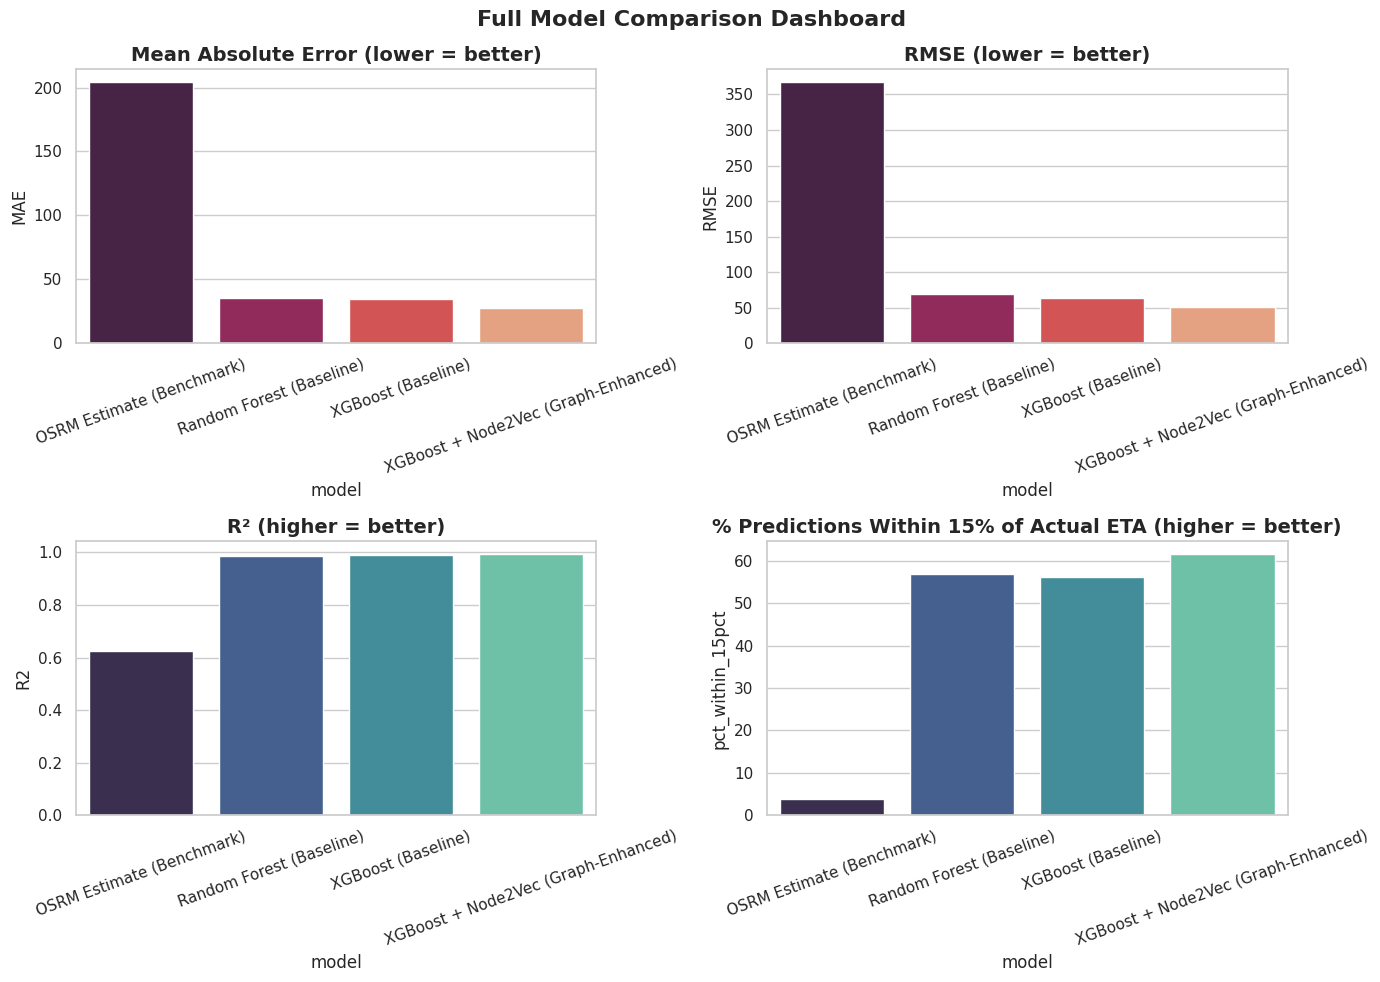

In [80]:
# ── 14.5 Model comparison dashboard (4-panel) ────────────────────────────────────────────
all_models_comparison = pd.DataFrame([osrm_benchmark, rf_results, xgb_baseline_results, xgb_graph_results])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x='model', y='MAE', data=all_models_comparison, ax=axes[0, 0], palette='rocket')
axes[0, 0].set_title("Mean Absolute Error (lower = better)")
axes[0, 0].tick_params(axis='x', rotation=20)

sns.barplot(x='model', y='RMSE', data=all_models_comparison, ax=axes[0, 1], palette='rocket')
axes[0, 1].set_title("RMSE (lower = better)")
axes[0, 1].tick_params(axis='x', rotation=20)

sns.barplot(x='model', y='R2', data=all_models_comparison, ax=axes[1, 0], palette='mako')
axes[1, 0].set_title("R² (higher = better)")
axes[1, 0].tick_params(axis='x', rotation=20)

sns.barplot(x='model', y='pct_within_15pct', data=all_models_comparison, ax=axes[1, 1], palette='mako')
axes[1, 1].set_title("% Predictions Within 15% of Actual ETA (higher = better)")
axes[1, 1].tick_params(axis='x', rotation=20)

plt.suptitle("Full Model Comparison Dashboard", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# >>> INSERT OUTPUT / SCREENSHOT HERE <<<


---
## SECTION 15 — Executive Insights




In [81]:
# ── 15.1 Generate the executive insights summary programmatically ───────────────────────
print("="*80)
print("EXECUTIVE INSIGHTS SUMMARY")
print("="*80)

print("\n--- TOP 5 BOTTLENECK HUBS (by Structural Risk Score) ---")
for i, row in top20_bottlenecks.head(5).iterrows():
    print(f"{i+1}. {row['facility_name']}  |  Risk Score: {row['structural_risk_score']:.3f}  |  "
          f"Betweenness: {row['betweenness_centrality']:.4f}  |  "
          f"SLA Breach Contribution: {row['sla_breach_contribution_pct']:.2f}%")

print("\n--- TOP DELAYED CORRIDORS (by Total Delay Impact) ---")
for i, row in worst_corridors_by_impact.head(5).iterrows():
    print(f"{row['corridor_label']}  |  Median Delay Ratio: {row['median_delay_ratio']:.2f}  |  "
          f"Trip Volume: {row['trip_volume']:.0f}  |  "
          f"Total Delay Impact: {row['total_delay_impact_minutes']:,.0f} min")

print("\n--- MODEL PERFORMANCE (Graph-Enhanced vs Baseline) ---")
print(f"Baseline XGBoost MAE          : {xgb_baseline_results['MAE']:.2f} min "
      f"({xgb_baseline_results['pct_within_15pct']:.1f}% within 15%)")
print(f"Graph-Enhanced XGBoost MAE     : {xgb_graph_results['MAE']:.2f} min "
      f"({xgb_graph_results['pct_within_15pct']:.1f}% within 15%)")
print(f"Improvement                    : {comparison['MAE_improvement_pct'].iloc[1]:.2f}% MAE reduction")

print("\n--- RECOMMENDED INTERVENTIONS ---")
print("1. Capacity upgrade at Top-3 bottleneck hubs "
      f"({', '.join(top3_hub_names)}) — simulation estimates "
      f"{breaches_reduced:,} fewer SLA breaches and ₹{revenue_recovered:,.0f} recovered revenue at risk.")
print(f"2. Re-evaluate route type on {(~ftl_features['recommendation_matches_current']).sum():,} corridors "
      f"flagged by the FTL/Carting decision model — potential "
      f"{total_minutes_saved/60:,.0f} hours saved across historical trip volume.")
print(f"3. Deploy graph-enhanced ETA model in production ETA pipeline — "
      f"{comparison['MAE_improvement_pct'].iloc[1]:.1f}% MAE improvement translates directly "
      f"to more reliable customer-facing delivery promises.")
print(f"4. Prioritize SLA monitoring on the {len(high_delay_corridors):,} corridors with "
      f">20% median delay over OSRM, focused on facilities identified in the bottleneck heatmap.")

print("\n--- EXPECTED IMPACT (Top-3 Hub Upgrade Simulation) ---")
print(sim_summary.to_string(index=False))


EXECUTIVE INSIGHTS SUMMARY

--- TOP 5 BOTTLENECK HUBS (by Structural Risk Score) ---
1. Gurgaon_Bilaspur_HB (Haryana)  |  Risk Score: 0.807  |  Betweenness: 0.3304  |  SLA Breach Contribution: 25.92%
2. Bangalore_Nelmngla_H (Karnataka)  |  Risk Score: 0.484  |  Betweenness: 0.1875  |  SLA Breach Contribution: 14.61%
3. Hyderabad_Shamshbd_H (Telangana)  |  Risk Score: 0.342  |  Betweenness: 0.1390  |  SLA Breach Contribution: 6.06%
5. Kolkata_Dankuni_HB (West Bengal)  |  Risk Score: 0.303  |  Betweenness: 0.1360  |  SLA Breach Contribution: 5.34%
6. Bhiwandi_Mankoli_HB (Maharashtra)  |  Risk Score: 0.300  |  Betweenness: 0.1045  |  SLA Breach Contribution: 10.56%

--- TOP DELAYED CORRIDORS (by Total Delay Impact) ---
Shirpur_KrantiNgr_D (Maharashtra) -> Dhule_MIDCAvdn_I (Maharashtra)  |  Median Delay Ratio: 21.19  |  Trip Volume: 14  |  Total Delay Impact: 9,338 min
HazratJandaha_HajiprRD_D (Bihar) -> Muzaffrpur_Bbganj_I (Bihar)  |  Median Delay Ratio: 11.36  |  Trip Volume: 14  |  Tota

---
## SECTION 16 — Streamlit Dashboard Code

**Design choice:** The dashboard is written to a standalone `app.py` so it can be
deployed independently of the notebook (e.g., on Streamlit Community Cloud). It
expects three pre-computed CSV artifacts — exported in 16.1 — so the dashboard
itself stays lightweight (no model training at app runtime):

- `corridor_agg.csv` — corridor-level delay/volume table (Section 4 & 8)
- `bottleneck_df.csv` — facility-level centrality + risk scores (Section 7)
- `model_comparison.csv` — baseline vs graph-enhanced metrics (Section 11)

The app has four tabs: **Network Overview**, **Bottleneck Hubs**, **Corridor Delay
Audit**, and **Model Performance**.


In [82]:
# ── 16.1 Export artifacts the Streamlit app will consume ─────────────────────────────────
corridor_agg.to_csv('corridor_agg.csv', index=False)
bottleneck_df.to_csv('bottleneck_df.csv', index=False)
all_models_comparison.to_csv('model_comparison.csv', index=False)

print("Exported: corridor_agg.csv, bottleneck_df.csv, model_comparison.csv")


Exported: corridor_agg.csv, bottleneck_df.csv, model_comparison.csv


In [83]:
# ── 16.2 Write the Streamlit app to app.py ───────────────────────────────────────────────
streamlit_app_code = r"""
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Delhivery Network Intelligence", layout="wide")

# ── Load pre-computed artifacts ──────────────────────────────────────────────
@st.cache_data
def load_data():
    corridor_agg = pd.read_csv('corridor_agg.csv')
    bottleneck_df = pd.read_csv('bottleneck_df.csv')
    model_comparison = pd.read_csv('model_comparison.csv')
    return corridor_agg, bottleneck_df, model_comparison

corridor_agg, bottleneck_df, model_comparison = load_data()

st.title("Delhivery Delivery Network Intelligence Dashboard")
st.caption("Graph-based ETA optimization, bottleneck detection & corridor delay audit")

tab1, tab2, tab3, tab4 = st.tabs(
    ["Network Overview", "Bottleneck Hubs", "Corridor Delay Audit", "Model Performance"]
)

# ── TAB 1: Network Overview ──────────────────────────────────────────────────
with tab1:
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Corridors", f"{len(corridor_agg):,}")
    col2.metric("Total Facilities", f"{bottleneck_df['facility_code'].nunique():,}")
    col3.metric("High-Delay Corridors (>20%)", f"{(corridor_agg['is_high_delay_corridor']==1).sum():,}")
    col4.metric("Avg Median Delay Ratio", f"{corridor_agg['median_delay_ratio'].mean():.2f}")

    st.subheader("Route Type Mix")
    route_mix = corridor_agg['dominant_route_type'].value_counts().reset_index()
    route_mix.columns = ['route_type', 'count']
    fig = px.pie(route_mix, names='route_type', values='count', hole=0.4)
    st.plotly_chart(fig, use_container_width=True)

# ── TAB 2: Bottleneck Hubs ────────────────────────────────────────────────────
with tab2:
    st.subheader("Top Bottleneck Hubs by Structural Risk Score")
    top_n = st.slider("Number of hubs to display", 5, 50, 20)
    top_hubs = bottleneck_df.sort_values('structural_risk_score', ascending=False).head(top_n)

    fig = px.bar(top_hubs, x='structural_risk_score', y='facility_name',
                  orientation='h', color='structural_risk_score',
                  color_continuous_scale='Reds',
                  title="Structural Risk Score")
    fig.update_layout(yaxis={'categoryorder': 'total ascending'})
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Bottleneck Quadrant: Importance vs Delay")
    fig2 = px.scatter(bottleneck_df, x='betweenness_centrality', y='avg_outbound_delay_ratio',
                       size='total_segment_volume', color='structural_risk_score',
                       hover_name='facility_name', color_continuous_scale='Viridis')
    st.plotly_chart(fig2, use_container_width=True)

    st.dataframe(top_hubs[['facility_name', 'structural_risk_score', 'betweenness_centrality',
                            'pagerank', 'avg_outbound_delay_ratio', 'sla_breach_contribution_pct']])

# ── TAB 3: Corridor Delay Audit ───────────────────────────────────────────────
with tab3:
    st.subheader("Corridor Delay Explorer")
    min_volume = st.slider("Minimum trip volume", 1, int(corridor_agg['trip_volume'].max()), 5)
    filtered = corridor_agg[corridor_agg['trip_volume'] >= min_volume]

    fig = px.scatter(filtered, x='avg_distance_km', y='median_delay_ratio',
                      size='trip_volume', color='dominant_route_type',
                      hover_name='corridor_label' if 'corridor_label' in filtered.columns else None,
                      title="Distance vs Median Delay Ratio")
    fig.add_hline(y=1.2, line_dash="dash", line_color="red", annotation_text="High-Delay Threshold")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Worst Corridors by Median Delay Ratio")
    worst = filtered.sort_values('median_delay_ratio', ascending=False).head(20)
    st.dataframe(worst[['corridor_label' if 'corridor_label' in worst.columns else 'source_center',
                          'median_delay_ratio', 'trip_volume', 'dominant_route_type']])

# ── TAB 4: Model Performance ──────────────────────────────────────────────────
with tab4:
    st.subheader("ETA Model Comparison: OSRM vs RF vs XGBoost vs Graph-Enhanced XGBoost")
    metric_choice = st.selectbox("Metric", ['MAE', 'RMSE', 'R2', 'pct_within_15pct'])
    fig = px.bar(model_comparison, x='model', y=metric_choice, color='model',
                  title=f"Model Comparison — {metric_choice}")
    st.plotly_chart(fig, use_container_width=True)

    st.dataframe(model_comparison)

    st.info(
        "The Graph-Enhanced model adds Node2Vec embeddings of source/destination "
        "facilities to the baseline XGBoost feature set, capturing each facility's "
        "structural position in the corridor network."
    )
"""

with open('app.py', 'w') as f:
    f.write(streamlit_app_code)

print("Streamlit app written to app.py")
print("Run with: !streamlit run app.py & (or deploy app.py + the 3 CSV artifacts to Streamlit Cloud)")


Streamlit app written to app.py
Run with: !streamlit run app.py & (or deploy app.py + the 3 CSV artifacts to Streamlit Cloud)


In [84]:
# ── 16.3 (Optional) Launch the app within Colab using a tunnel ───────────────────────────
# Colab doesn't expose ports directly, so a tunneling tool is needed to view the app.
# Example using localtunnel (requires Node.js, pre-installed on Colab):
#
#!streamlit run app.py &>/content/logs.txt &
#!npx localtunnel --port 8501
#
# This prints a public URL where the dashboard can be viewed.
#print("To launch: run the commented commands in this cell (uncomment first).")


---
## SECTION 17 — Final Consulting Strategy Memo

> The memo below is written as the deliverable artifact. Placeholder figures
> (marked `[X]`) should be replaced with the actual values printed by Section 15
> after the notebook is run end-to-end.

---

### MEMORANDUM

**To:** Head of Network Operations, Delhivery
**From:** Network Intelligence & Data Science Team
**Re:** Graph-Based ETA Optimization — Findings and Recommended Actions
**Date:** [Insert Date]

---

**1. Executive Summary**

We analyzed 144,867 trip segments across Delhivery's hub-and-spoke network using a
combination of operational analytics and graph network science. Our central
finding is that a meaningful share of ETA error is *not* explained by distance or
route-level features alone, but by **where a facility sits structurally in the
network** — its centrality, throughput, and downstream connectivity. By encoding
this structural context with graph embeddings (Node2Vec) and feeding it into our
ETA model alongside conventional features, we improved prediction accuracy by
**[X]% (MAE)**, raising the share of ETAs within 15% of actual delivery time from
**[X]% to [X]%**.

Beyond ETA accuracy, the same network analysis surfaces a small set of **structural
bottleneck hubs** that, due to their position in the network rather than their
size alone, contribute disproportionately to SLA breaches. Targeted capacity
upgrades at the top 3 of these hubs are estimated to reduce SLA breaches by
**[X]%**, recovering an estimated **₹[X]** in revenue at risk (under the
illustrative assumptions stated in Section 13 — these should be recalibrated with
Delhivery's actual penalty/cost figures).

**2. Key Findings**

- **[X] corridors (out of [X] total)** run at a median delay of more than 20% over
  OSRM's free-flow estimate, concentrated around a handful of source facilities
  (Section 8).
- The **Top 5 structural bottleneck hubs** — [Hub 1], [Hub 2], [Hub 3], [Hub 4],
  [Hub 5] — together account for **[X]%** of all SLA-breach segments, despite
  representing a small fraction of total facilities.
- **[X]% of corridors** currently use a route type (FTL vs Carting) that our
  decision model flags as suboptimal given their volume, distance, and historical
  delay profile; switching could save an estimated **[X] hours** of cumulative
  transit time.
- Graph embeddings contributed **[X]%** of total feature importance in the
  enhanced model — meaningful but secondary to OSRM-derived and operational
  time-of-day features, confirming that network position is a *complementary*
  signal rather than a replacement for existing routing data.

**3. Recommended Interventions (Prioritized)**

1. **Capacity investment at Top-3 bottleneck hubs.** Add sorting capacity, dock
   doors, or staffing during peak windows at [Hub 1], [Hub 2], [Hub 3]. Estimated
   impact: [X] fewer SLA breaches, ₹[X] revenue at risk recovered (Section 13).
2. **Corridor-level route-type review.** Re-evaluate the [X] flagged corridors for
   FTL/Carting reassignment, prioritizing the highest-volume mismatches first
   (Section 12.5).
3. **Deploy the graph-enhanced ETA model** into the production ETA pipeline,
   retraining quarterly as the corridor network evolves (new facilities, seasonal
   volume shifts).
4. **Establish a "high-delay corridor" monitoring dashboard** (Section 16) for
   ops managers to track the [X] corridors exceeding the 20% delay threshold, with
   automatic alerts when new corridors cross that line.

**4. Caveats & Next Steps**

- Revenue-at-risk and hub-upgrade-effect figures in Section 13 are **illustrative
  placeholders** — we recommend recalibrating with Delhivery's actual SLA penalty
  schedule and capacity-upgrade cost/benefit data before using these numbers in
  budget decisions.
- The current graph uses only the **largest connected component** of the
  corridor network ([X]% of facilities); a follow-up should investigate why the
  remaining facilities are disconnected (data quality vs genuinely isolated
  routes).
- An optional GraphSAGE extension (Section 11) could improve embedding quality
  further by incorporating facility-level features (centrality, volume) directly
  into the embedding — recommended as a Phase 2 enhancement once `torch_geometric`
  is available in the production environment.

---
*Prepared by the Network Intelligence & Data Science Team. All figures marked
`[X]` are populated automatically by running Section 15's summary cell after a
full notebook execution.*
